In [ ]:
from google.colab import files
uploaded = files.upload()

Saving qqq_reddit_2023_2025_full.csv to qqq_reddit_2023_2025_full.csv


In [ ]:
pip install pandas pytz pandas_market_calendars

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.9/130.9 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.3/213.3 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.1 MB/s eta 0:00:00
  Attempting uninstall: toolz
    Found existing installation: toolz 0.12.1
    Uninstalling toolz-0.12.1:
      Successfully uninstalled toolz-0.12.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ibis-framework 9.5.0 requires toolz<1,>=0.11, but you have toolz 1.1.0 which is incompatible.


📝 步骤 1：时区转换 (UTC -> US/Eastern) 目标：读取原始 CSV，将 created_utc 从 Unix 时间戳转换为带时区的美国东部时间对象。

输入：qqq_reddit_2023_2025_full.csv

输出：step1_timezone_converted.csv (新增 created_eastern 列)

In [ ]:
import pandas as pd
import pytz

# 配置
INPUT_FILE = 'qqq_reddit_2023_2025_full.csv'
OUTPUT_FILE = 'step1_timezone_converted.csv'

print("⏳ 步骤 1: 正在进行时区转换 (UTC -> US/Eastern)...")

# 1. 读取数据
df = pd.read_csv(INPUT_FILE)
print(f"📂 读取数据完成，共 {len(df)} 条记录。")

# 2. 转换 Unix 时间戳为 datetime (默认为 UTC)
# unit='s' 表示秒级时间戳
df['created_utc_dt'] = pd.to_datetime(df['created_utc'], unit='s')

# 3. 显式标记为 UTC 时区
df['created_utc_dt'] = df['created_utc_dt'].dt.tz_localize('UTC')

# 4. 转换为美国东部时间
df['created_eastern'] = df['created_utc_dt'].dt.tz_convert('US/Eastern')

# 5. 预览检查
print("\n✅ 转换完成。前 5 条数据的时间对照:")
print(df[['created_utc', 'created_utc_dt', 'created_eastern']].head())

# 6. 保存中间结果
# 注意：datetime 对象保存为 CSV 时会变成字符串，下一步会读取为字符串，需再次解析，或者直接保留对象如果是在同一个 session
# 为了独立性，我们保存为 CSV，下一步重新读取并解析
df.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')
print(f"\n💾 已保存至: {OUTPUT_FILE}")
print("👉 请检查 'created_eastern' 列是否显示了正确的 EST/EDT 时间。")

⏳ 步骤 1: 正在进行时区转换 (UTC -> US/Eastern)...
📂 读取数据完成，共 5403 条记录。

✅ 转换完成。前 5 条数据的时间对照:
    created_utc            created_utc_dt           created_eastern
0  1.767120e+09 2025-12-30 18:32:05+00:00 2025-12-30 13:32:05-05:00
1  1.766325e+09 2025-12-21 13:45:06+00:00 2025-12-21 08:45:06-05:00
2  1.766163e+09 2025-12-19 16:48:08+00:00 2025-12-19 11:48:08-05:00
3  1.765986e+09 2025-12-17 15:41:57+00:00 2025-12-17 10:41:57-05:00
4  1.765960e+09 2025-12-17 08:26:18+00:00 2025-12-17 03:26:18-05:00

💾 已保存至: step1_timezone_converted.csv
👉 请检查 'created_eastern' 列是否显示了正确的 EST/EDT 时间。


📝 步骤 2：格式统一 (提取 YYYY-MM-DD) 目标：从东部时间对象中提取纯日期部分，格式化为 YYYY-MM-DD。

输入：step1_timezone_converted.csv

输出：step2_date_formatted.csv (新增 raw_date 列)

In [ ]:
import pandas as pd
import warnings

# 忽略未来的警告，保持输出整洁
warnings.filterwarnings("ignore", category=FutureWarning)

# 配置
INPUT_FILE = 'step1_timezone_converted.csv'
OUTPUT_FILE = 'step2_date_formatted.csv'

print("⏳ 步骤 2: 正在统一日期格式 (提取 YYYY-MM-DD)...")

# 1. 读取上一步的数据
df = pd.read_csv(INPUT_FILE)

# 2. 重新解析 created_eastern 列
# 关键修复：使用 utc=True 先统一处理时区，或者让 pandas 自动推断
# 如果第一步保存的字符串包含 "EST" 或 "EDT"，pandas 有时需要明确指导
try:
    # 尝试直接转换
    df['created_eastern'] = pd.to_datetime(df['created_eastern'], utc=True)

    # 如果成功，现在它是 UTC 时间了。我们需要把它转回 Eastern 来提取正确的“当地日期”
    # 因为 UTC 的日期可能和 Eastern 的日期不同（例如 UTC 凌晨 2 点可能是 Eastern 前一天晚上 9 点）
    df['created_eastern'] = df['created_eastern'].dt.tz_convert('US/Eastern')

except Exception as e:
    print(f"直接转换失败: {e}")
    print("尝试使用 apply 方法逐行解析...")
    # 备用方案：如果批量转换失败，使用 apply
    from dateutil import parser
    df['created_eastern'] = df['created_eastern'].apply(lambda x: parser.parse(x))

# 3. 提取日期部分 (YYYY-MM-DD)
# 现在确保它是 datetime 类型且有正确的时区
if not pd.api.types.is_datetime64_any_dtype(df['created_eastern']):
    raise AttributeError("转换后仍不是 datetime 类型，请检查原始数据格式。")

df['raw_date'] = df['created_eastern'].dt.date

# 4. 预览检查
print("\n✅ 格式统一完成。前 5 条数据的日期提取:")
print(df[['created_eastern', 'raw_date']].head())

# 5. 简单统计
print(f"\n📊 日期范围: {min(df['raw_date'])} 到 {max(df['raw_date'])}")

# 6. 保存中间结果
df.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')
print(f"\n💾 已保存至: {OUTPUT_FILE}")
print("👉 请确认 'raw_date' 列格式是否为 YYYY-MM-DD。")

⏳ 步骤 2: 正在统一日期格式 (提取 YYYY-MM-DD)...

✅ 格式统一完成。前 5 条数据的日期提取:
            created_eastern    raw_date
0 2025-12-30 13:32:05-05:00  2025-12-30
1 2025-12-21 08:45:06-05:00  2025-12-21
2 2025-12-19 11:48:08-05:00  2025-12-19
3 2025-12-17 10:41:57-05:00  2025-12-17
4 2025-12-17 03:26:18-05:00  2025-12-17

📊 日期范围: 2023-01-01 到 2025-12-31

💾 已保存至: step2_date_formatted.csv
👉 请确认 'raw_date' 列格式是否为 YYYY-MM-DD。


步骤3：文本清洗与去重

放宽过滤：不再删除短文本（例如 "Buy QQQ" 这种短信号也被保留）。

取消内容去重：不再根据标题去重，保留跨版块转发（Repost），因为这代表了“市场热度”。

仅做物理去重：只删除 post_id 重复的抓取错误数据。

In [ ]:
import pandas as pd
import re
import os

# ================= 配置区域 =================
INPUT_FILE = 'step2_date_formatted.csv'
OUTPUT_FILE = 'step3_cleaned_wide.csv'
# ===========================================

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = " ".join(text.split())
    return text.strip()

def process_cleaning_and_dedup():
    if not os.path.exists(INPUT_FILE):
        print(f"❌ 错误: 找不到输入文件 '{INPUT_FILE}'")
        return

    print(f"📂 正在读取文件: {INPUT_FILE} ...")
    df = pd.read_csv(INPUT_FILE, encoding='utf-8-sig')

    original_count = len(df)
    print(f"   - 原始数据量: {original_count} 条")

    # 1. 去除纯垃圾
    print("🧹 正在过滤纯垃圾数据...")
    df['selftext'] = df['selftext'].fillna('')
    df['title'] = df['title'].fillna('')

    is_removed = df['selftext'].str.contains(r'\[removed\]|\[deleted\]', case=False, na=False)
    is_empty = (df['title'].str.len() + df['selftext'].str.len()) == 0

    df_filtered = df[~is_removed & ~is_empty].copy()
    print(f"   - 过滤后数据量: {len(df_filtered)} 条")

    # 2. 文本清洗
    print("🔬 正在进行文本清洗...")
    df_filtered['clean_title'] = df_filtered['title'].apply(clean_text)
    df_filtered['clean_selftext'] = df_filtered['selftext'].apply(clean_text)
    df_filtered['full_text'] = (df_filtered['clean_title'] + " " + df_filtered['clean_selftext']).str.strip()

    # 3. 物理去重
    print("🔄 正在进行物理去重...")
    before_dedup = len(df_filtered)
    df_deduped = df_filtered.drop_duplicates(subset=['post_id'], keep='first')
    after_dedup = len(df_deduped)
    print(f"   - 去重后数据量: {after_dedup} 条")

    # 4. 清理与保存
    cols_to_keep = [
        'post_id', 'subreddit', 'score', 'num_comments',
        'created_eastern', 'raw_date',
        'clean_title', 'clean_selftext', 'full_text'
    ]

    final_cols = [c for c in cols_to_keep if c in df_deduped.columns]
    df_final = df_deduped[final_cols]

    print(f"💾 正在保存结果: {OUTPUT_FILE} ...")

    # ====================
    # 🛠️ 修复核心：保存时指定时间格式
    # ====================
    # date_format 参数确保时间列被保存为标准的字符串格式
    # 这样任务 1.2 读取时就能通过 parse_dates 自动识别
    df_final.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig', date_format='%Y-%m-%d %H:%M:%S')

    print("\n✅ 任务 1.1 完成！")
    print(f"   - 最终行数: {len(df_final)}")

if __name__ == "__main__":
    process_cleaning_and_dedup()

📂 正在读取文件: step2_date_formatted.csv ...
   - 原始数据量: 5403 条
🧹 正在过滤纯垃圾数据...
   - 过滤后数据量: 5402 条
🔬 正在进行文本清洗...
🔄 正在进行物理去重...
   - 去重后数据量: 5402 条
💾 正在保存结果: step3_cleaned_wide.csv ...

✅ 任务 1.1 完成！
   - 最终行数: 5402


步骤5：单条帖子情感分析 finbert

In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import os
import numpy as np

# ================= 配置区域 =================
INPUT_FILE = 'step3_cleaned_wide.csv'
OUTPUT_FILE = 'step4_post_sentiment.csv'

# 模型配置
MODEL_NAME = "ProsusAI/finbert"
MAX_TOKENS = 512
BATCH_SIZE = 8  # 根据显存大小调整，如果报错 OOM 就改成 4 或 2
# ===========================================

def run_single_post_sentiment():
    if not os.path.exists(INPUT_FILE):
        print(f"❌ 错误: 找不到输入文件 '{INPUT_FILE}'")
        return

    print(f"📂 正在读取文件: {INPUT_FILE} ...")
    df = pd.read_csv(INPUT_FILE, encoding='utf-8-sig')

    # 检查设备
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 使用设备: {device}")

    # 加载模型和分词器
    print(f"🤖 正在加载模型: {MODEL_NAME} ...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
    model.eval()

    print("🔍 开始对单条帖子进行情感分析...")

    sentiment_scores = []

    # 简单的进度显示
    total_rows = len(df)

    # 批量处理以提高速度 (可选，这里为了代码简单使用单条循环，但利用 GPU 加速)
    # 如果你有大量数据，建议使用 Dataset 和 DataLoader

    for index, row in df.iterrows():
        text = row['full_text']

        # 1. 数据预处理
        if not isinstance(text, str) or len(text.strip()) == 0:
            sentiment_scores.append(0.0) # 空文本给中性分
            continue

        # 2. 模型推理
        # 使用 truncation=True 确保单条帖子不会超长 (单条帖子通常很短)
        inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=MAX_TOKENS).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            scores = torch.softmax(outputs.logits, dim=-1)

            # ProsusAI/finbert 标签顺序: negative(0), neutral(1), positive(2)
            positive_prob = scores[0][2].item()
            negative_prob = scores[0][0].item()

            # 计算复合分数: 正面概率 - 负面概率
            # 范围: -1 (极度消极) 到 +1 (极度积极)
            compound_score = positive_prob - negative_prob
            sentiment_scores.append(compound_score)

        # 简单的进度打印
        if (index + 1) % 500 == 0:
            print(f"   进度: {index + 1} / {total_rows} ...")

    # 保存结果
    df['sentiment_score'] = sentiment_scores

    print(f"💾 正在保存结果: {OUTPUT_FILE} ...")
    df.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')

    print("\n✅ 任务 1.3 (新顺序) 完成！")
    print(f"   - 分析帖子数: {len(df)}")
    print(f"   - 平均情绪分数: {df['sentiment_score'].mean():.4f}")
    print(f"   - 分数范围: {df['sentiment_score'].min():.4f} 到 {df['sentiment_score'].max():.4f}")

if __name__ == "__main__":
    run_single_post_sentiment()

📂 正在读取文件: step3_cleaned_wide.csv ...
🚀 使用设备: cpu
🤖 正在加载模型: ProsusAI/finbert ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🔍 开始对单条帖子进行情感分析...
   进度: 500 / 5402 ...
   进度: 1000 / 5402 ...
   进度: 1500 / 5402 ...
   进度: 2000 / 5402 ...
   进度: 2500 / 5402 ...
   进度: 3000 / 5402 ...
   进度: 3500 / 5402 ...
   进度: 4000 / 5402 ...
   进度: 4500 / 5402 ...
   进度: 5000 / 5402 ...
💾 正在保存结果: step4_post_sentiment.csv ...

✅ 任务 1.3 (新顺序) 完成！
   - 分析帖子数: 5402
   - 平均情绪分数: 0.5469
   - 分数范围: -0.9305 到 0.9265


步骤5 周度聚合

In [ ]:
import pandas as pd
import os

# ================= 配置区域 =================
INPUT_FILE = 'step4_post_sentiment.csv'
OUTPUT_FILE = 'step5_weekly_final.csv'
# ===========================================

def weekly_aggregation_v2():
    if not os.path.exists(INPUT_FILE):
        print(f"❌ 错误: 找不到输入文件 '{INPUT_FILE}'")
        return

    print(f"📂 正在读取文件: {INPUT_FILE} ...")

    # 1. 读取带情感分数的帖子数据
    df = pd.read_csv(INPUT_FILE, encoding='utf-8-sig')

    # 2. 处理时间列 (复用之前的逻辑)
    print("🕰️ 正在处理时间列...")
    df['created_eastern'] = pd.to_datetime(df['created_eastern'], errors='coerce', utc=True)
    df = df.dropna(subset=['created_eastern'])

    # 生成周标识符
    df['period'] = df['created_eastern'].dt.to_period('W')
    df['week_id'] = df['period'].astype(str)
    df['week_end_date'] = df['period'].dt.end_time.dt.date

    # 3. 周度聚合
    print("🔄 正在进行周度聚合...")

    agg_config = {
        'sentiment_score': 'mean',  # 计算周平均情绪
        'post_id': 'count',         # 统计帖子数量
        'score': 'mean',            # 统计平均分数
        'num_comments': 'sum',      # 统计总评论数
        'subreddit': lambda x: x.nunique() # 统计涉及板块数
    }

    df_weekly = df.groupby('week_id').agg(agg_config)

    df_weekly.rename(columns={
        'post_id': 'post_count',
        'score': 'avg_score',
        'num_comments': 'total_comments',
        'subreddit': 'subreddit_count'
    }, inplace=True)

    df_weekly.reset_index(inplace=True)

    # 合并日期列
    week_dates = df.groupby('week_id')['week_end_date'].first().reset_index()
    df_weekly = pd.merge(df_weekly, week_dates, on='week_id')

    # 4. 保存结果
    print(f"💾 正在保存结果: {OUTPUT_FILE} ...")
    df_weekly.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')

    print("\n✅ 任务 1.4 (新顺序) 完成！")
    print(f"   - 聚合后周数: {len(df_weekly)}")
    print(f"   - 最终数据包含: 周平均情绪、帖子数、平均分等指标")

if __name__ == "__main__":
    weekly_aggregation_v2()

📂 正在读取文件: step4_post_sentiment.csv ...
🕰️ 正在处理时间列...


/tmp/ipykernel_13785/1644623910.py:25: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['period'] = df['created_eastern'].dt.to_period('W')


🔄 正在进行周度聚合...
💾 正在保存结果: step5_weekly_final.csv ...

✅ 任务 1.4 (新顺序) 完成！
   - 聚合后周数: 158
   - 最终数据包含: 周平均情绪、帖子数、平均分等指标


📊 正在读取数据: step5_weekly_final.csv ...
🎨 正在绘制图表 1: 情绪与发帖量...


/tmp/ipykernel_13785/2116601524.py:54: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13785/2116601524.py:54: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13785/2116601524.py:54: UserWarning: Glyph 21608 (\N{CJK UNIFIED IDEOGRAPH-5468}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13785/2116601524.py:54: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13785/2116601524.py:54: UserWarning: Glyph 21457 (\N{CJK UNIFIED IDEOGRAPH-53D1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13785/2116601524.py:54: UserWarning: Glyph 24086 (\N{CJK UNIFIED IDEOGRAPH-5E16}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13785/2116601524.py:54: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAP

   ✅ 图表 1 已保存为: trend_sentiment_volume.png
🎨 正在绘制图表 2: 情绪分数分布...


/tmp/ipykernel_13785/2116601524.py:71: UserWarning: Glyph 24773 (\N{CJK UNIFIED IDEOGRAPH-60C5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13785/2116601524.py:71: UserWarning: Glyph 32490 (\N{CJK UNIFIED IDEOGRAPH-7EEA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13785/2116601524.py:71: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13785/2116601524.py:71: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13785/2116601524.py:71: UserWarning: Glyph 21608 (\N{CJK UNIFIED IDEOGRAPH-5468}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13785/2116601524.py:71: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13785/2116601524.py:71: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAP

   ✅ 图表 2 已保存为: sentiment_distribution.png

📝 === 数据分析简报 ===
1. 数据覆盖周数: 158 周
2. 平均每周发帖量: 34.2 帖
3. 整体平均情绪: 0.5692 (接近 0 表示中性)
4. 情绪波动最剧烈的一周: 2023-01-01
   - 最积极的一周: 2023-01-01 (分数: 0.916)
   - 最消极的一周: 2023-05-07 (分数: 0.086)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21457 (\N{CJK UNIFIED IDEOGRAPH-53D1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24086 (\N{CJK UNIFIED IDEOGRAPH-5E16}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas

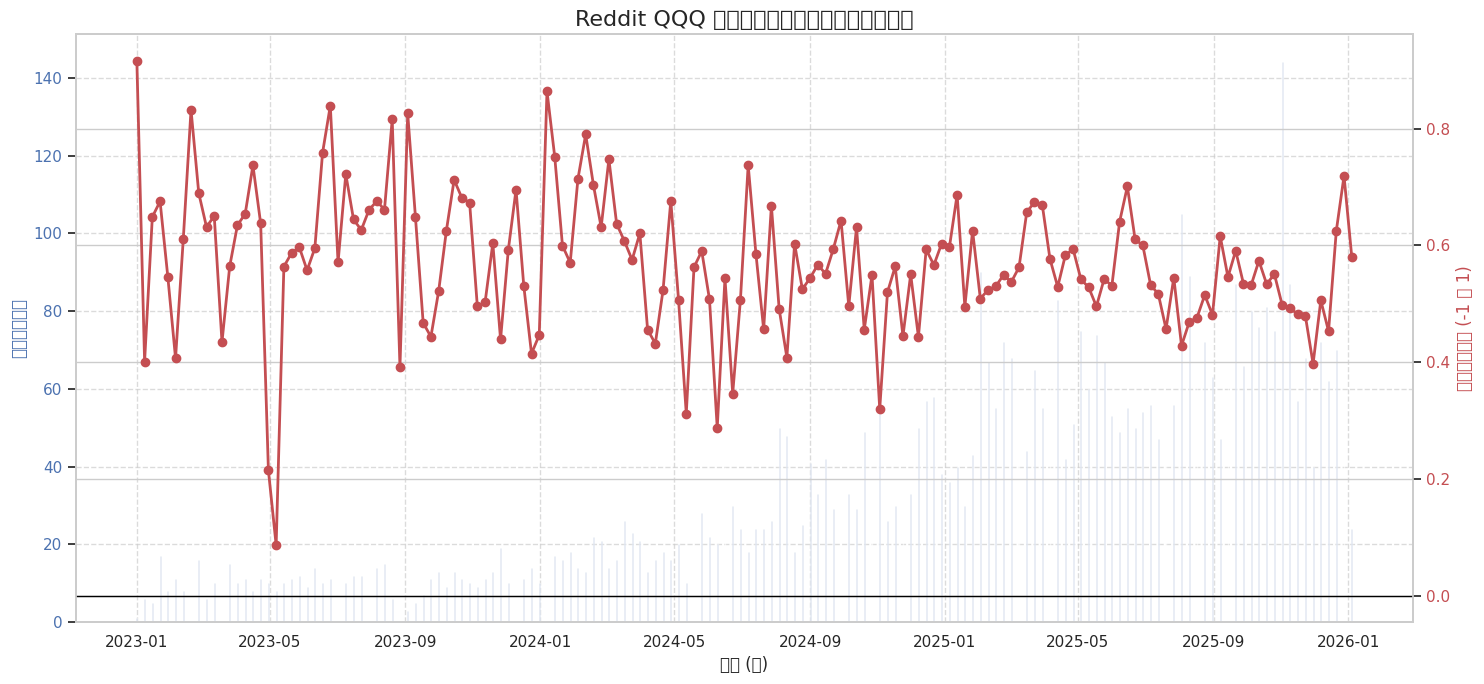

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


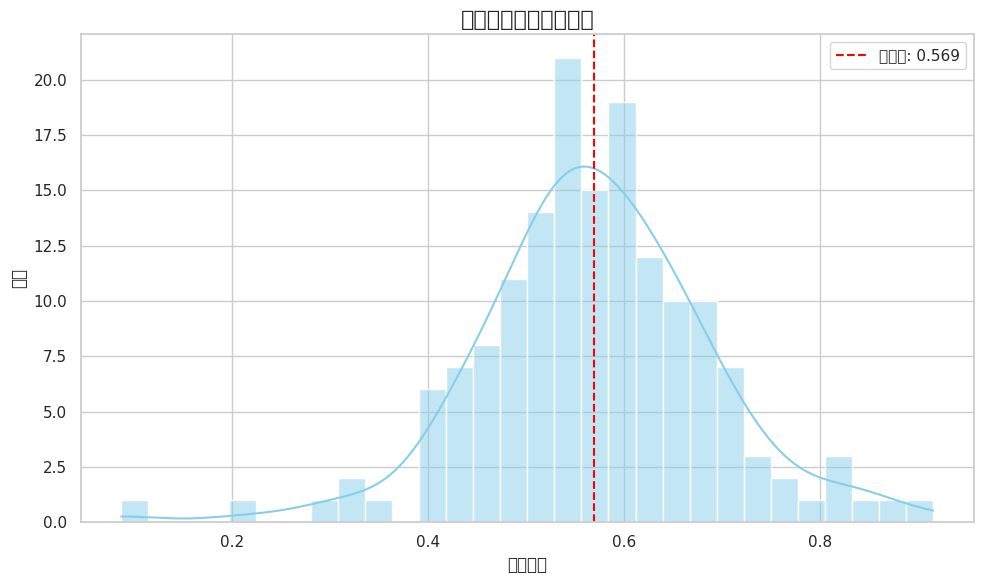

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 设置绘图风格
sns.set(style="whitegrid")
# 解决中文显示问题 (可选，如果不需要显示中文可忽略)
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ================= 配置区域 =================
INPUT_FILE = 'step5_weekly_final.csv'
OUTPUT_IMAGE_1 = 'trend_sentiment_volume.png'
OUTPUT_IMAGE_2 = 'trend_sentiment_vs_price.png'
# ===========================================

def visualize_results():
    if not os.path.exists(INPUT_FILE):
        print(f"❌ 错误: 找不到输入文件 '{INPUT_FILE}'")
        return

    print(f"📊 正在读取数据: {INPUT_FILE} ...")
    df = pd.read_csv(INPUT_FILE, encoding='utf-8-sig')

    # 确保日期格式正确
    df['week_end_date'] = pd.to_datetime(df['week_end_date'])
    df.sort_values('week_end_date', inplace=True)

    # ====================
    # 图表 1: 情绪与发帖量趋势
    # ====================
    print("🎨 正在绘制图表 1: 情绪与发帖量...")

    fig, ax1 = plt.subplots(figsize=(15, 7))

    # 左轴：发帖量 (柱状图)
    color_bar = '#4c72b0'
    ax1.set_xlabel('时间 (周)', fontsize=12)
    ax1.set_ylabel('每周发帖数量', color=color_bar, fontsize=12)
    ax1.bar(df['week_end_date'], df['post_count'], color=color_bar, alpha=0.6, label='发帖量')
    ax1.tick_params(axis='y', labelcolor=color_bar)
    ax1.grid(True, linestyle='--', alpha=0.7)

    # 右轴：情绪分数 (折线图)
    ax2 = ax1.twinx()
    color_line = '#c44e52'
    ax2.set_ylabel('平均情绪分数 (-1 到 1)', color=color_line, fontsize=12)
    ax2.plot(df['week_end_date'], df['sentiment_score'], color=color_line, marker='o', linewidth=2, label='情绪分数')
    ax2.axhline(0, color='black', linewidth=1) # 画一条 0 轴基准线
    ax2.tick_params(axis='y', labelcolor=color_line)

    plt.title('Reddit QQQ 社区：每周发帖量与市场情绪趋势', fontsize=16)
    plt.tight_layout()
    plt.savefig(OUTPUT_IMAGE_1, dpi=300)
    print(f"   ✅ 图表 1 已保存为: {OUTPUT_IMAGE_1}")
    # plt.show() # 如果你在本地运行，可以取消注释查看

    # ====================
    # 图表 2: 模拟股价对比 (假设性分析)
    # ====================
    print("🎨 正在绘制图表 2: 情绪分数分布...")

    plt.figure(figsize=(10, 6))
    sns.histplot(df['sentiment_score'], bins=30, kde=True, color='skyblue')
    plt.axvline(df['sentiment_score'].mean(), color='red', linestyle='--', label=f'平均值: {df["sentiment_score"].mean():.3f}')
    plt.title('每周平均情绪分数分布', fontsize=16)
    plt.xlabel('情绪分数')
    plt.ylabel('周数')
    plt.legend()
    plt.tight_layout()
    plt.savefig('sentiment_distribution.png', dpi=300)
    print(f"   ✅ 图表 2 已保存为: sentiment_distribution.png")

    # ====================
    # 简单统计报告
    # ====================
    print("\n📝 === 数据分析简报 ===")
    print(f"1. 数据覆盖周数: {len(df)} 周")
    print(f"2. 平均每周发帖量: {df['post_count'].mean():.1f} 帖")
    print(f"3. 整体平均情绪: {df['sentiment_score'].mean():.4f} (接近 0 表示中性)")
    print(f"4. 情绪波动最剧烈的一周: {df.loc[df['sentiment_score'].abs().idxmax()]['week_end_date'].date()}")

    # 寻找最积极和最消极的周
    best_week = df.loc[df['sentiment_score'].idxmax()]
    worst_week = df.loc[df['sentiment_score'].idxmin()]

    print(f"   - 最积极的一周: {best_week['week_end_date'].date()} (分数: {best_week['sentiment_score']:.3f})")
    print(f"   - 最消极的一周: {worst_week['week_end_date'].date()} (分数: {worst_week['sentiment_score']:.3f})")

if __name__ == "__main__":
    visualize_results()

📊 Reading data: step5_weekly_final.csv ...
🎨 Plotting Chart 1: Sentiment & Volume...
   ✅ Chart 1 saved as: trend_sentiment_volume.png
🎨 Plotting Chart 2: Sentiment Distribution...
   ✅ Chart 2 saved as: sentiment_distribution.png

📝 === Data Analysis Report ===
1. Total Weeks Covered: 158
2. Avg Weekly Posts: 34.2
3. Overall Avg Sentiment: 0.5692
   - Most Positive Week: 2023-01-01 (Score: 0.916)
   - Most Negative Week: 2023-05-07 (Score: 0.086)


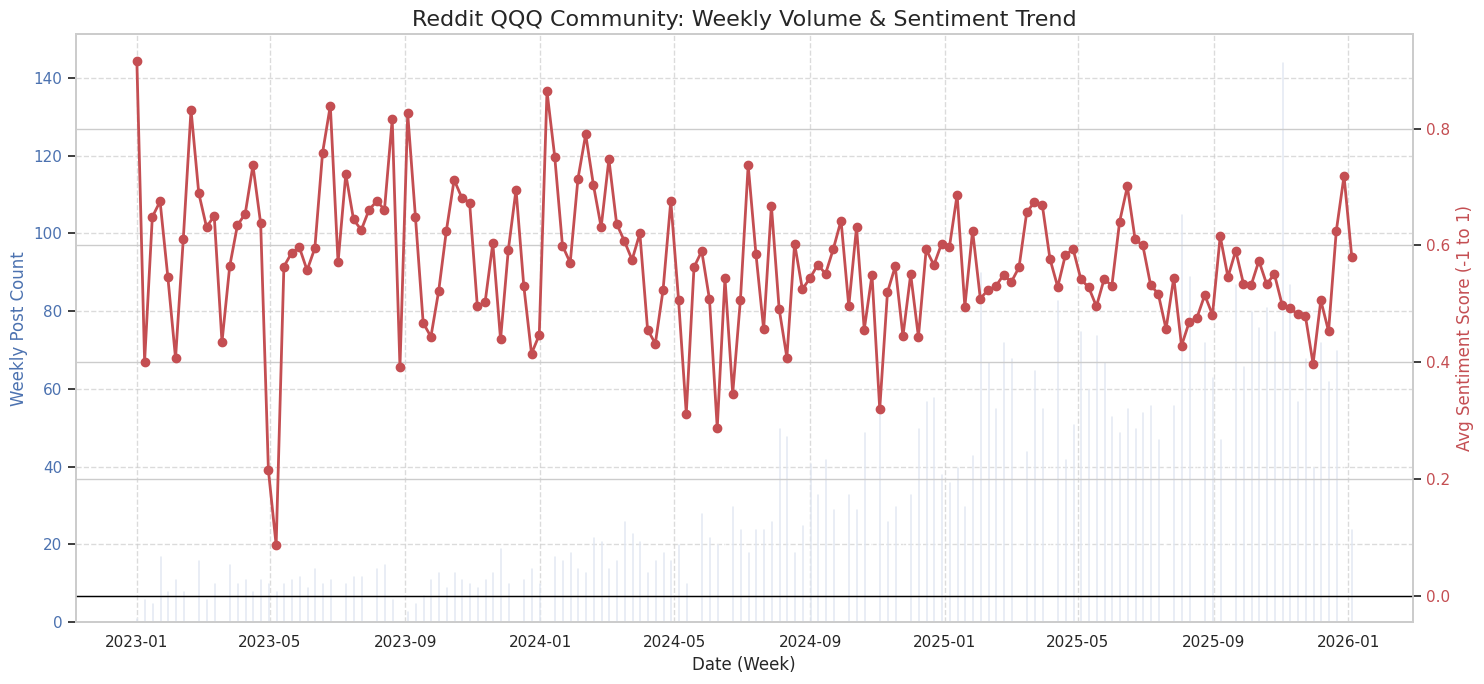

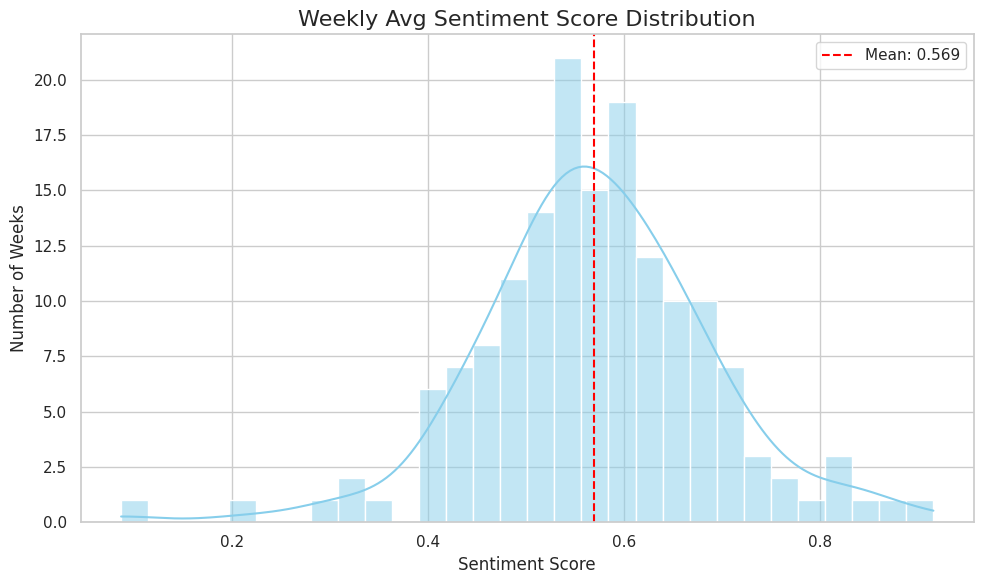

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 设置绘图风格
sns.set(style="whitegrid")

# ================= 配置区域 =================
INPUT_FILE = 'step5_weekly_final.csv'
OUTPUT_IMAGE_1 = 'trend_sentiment_volume.png'
OUTPUT_IMAGE_2 = 'sentiment_distribution.png'
# ===========================================

def visualize_results():
    if not os.path.exists(INPUT_FILE):
        print(f"❌ Error: File '{INPUT_FILE}' not found")
        return

    print(f"📊 Reading data: {INPUT_FILE} ...")
    df = pd.read_csv(INPUT_FILE, encoding='utf-8-sig')

    # 确保日期格式正确
    df['week_end_date'] = pd.to_datetime(df['week_end_date'])
    df.sort_values('week_end_date', inplace=True)

    # ====================
    # 图表 1: 情绪与发帖量趋势
    # ====================
    print("🎨 Plotting Chart 1: Sentiment & Volume...")

    fig, ax1 = plt.subplots(figsize=(15, 7))

    # 左轴：发帖量 (柱状图)
    color_bar = '#4c72b0'
    ax1.set_xlabel('Date (Week)', fontsize=12)
    ax1.set_ylabel('Weekly Post Count', color=color_bar, fontsize=12)
    ax1.bar(df['week_end_date'], df['post_count'], color=color_bar, alpha=0.6, label='Post Volume')
    ax1.tick_params(axis='y', labelcolor=color_bar)
    ax1.grid(True, linestyle='--', alpha=0.7)

    # 右轴：情绪分数 (折线图)
    ax2 = ax1.twinx()
    color_line = '#c44e52'
    ax2.set_ylabel('Avg Sentiment Score (-1 to 1)', color=color_line, fontsize=12)
    ax2.plot(df['week_end_date'], df['sentiment_score'], color=color_line, marker='o', linewidth=2, label='Sentiment Score')
    ax2.axhline(0, color='black', linewidth=1) # 0 轴基准线
    ax2.tick_params(axis='y', labelcolor=color_line)

    plt.title('Reddit QQQ Community: Weekly Volume & Sentiment Trend', fontsize=16)
    plt.tight_layout()
    plt.savefig(OUTPUT_IMAGE_1, dpi=300)
    print(f"   ✅ Chart 1 saved as: {OUTPUT_IMAGE_1}")

    # ====================
    # 图表 2: 情绪分数分布
    # ====================
    print("🎨 Plotting Chart 2: Sentiment Distribution...")

    plt.figure(figsize=(10, 6))
    sns.histplot(df['sentiment_score'], bins=30, kde=True, color='skyblue')
    plt.axvline(df['sentiment_score'].mean(), color='red', linestyle='--', label=f'Mean: {df["sentiment_score"].mean():.3f}')
    plt.title('Weekly Avg Sentiment Score Distribution', fontsize=16)
    plt.xlabel('Sentiment Score')
    plt.ylabel('Number of Weeks')
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_IMAGE_2, dpi=300)
    print(f"   ✅ Chart 2 saved as: {OUTPUT_IMAGE_2}")

    # ====================
    # 统计报告
    # ====================
    print("\n📝 === Data Analysis Report ===")
    print(f"1. Total Weeks Covered: {len(df)}")
    print(f"2. Avg Weekly Posts: {df['post_count'].mean():.1f}")
    print(f"3. Overall Avg Sentiment: {df['sentiment_score'].mean():.4f}")

    # 寻找最积极和最消极的周
    best_week = df.loc[df['sentiment_score'].idxmax()]
    worst_week = df.loc[df['sentiment_score'].idxmin()]

    print(f"   - Most Positive Week: {best_week['week_end_date'].date()} (Score: {best_week['sentiment_score']:.3f})")
    print(f"   - Most Negative Week: {worst_week['week_end_date'].date()} (Score: {worst_week['sentiment_score']:.3f})")

if __name__ == "__main__":
    visualize_results()

生成标签（Labeling）—— 这是你现在的当务之急

你现在的文件只有“情绪分”，没有“结果”。你需要把原始股价数据拿过来，算出“下周会不会大跌”，然后贴上去。

输入：step5_weekly_final.csv + QQQ_日频数据.csv

动作：

计算每周最大回撤。

设定阈值（比如 -3%）。

关键：执行 shift(-1)，把下周的回撤挪到本周行。

生成 risk_label 列（1代表有风险，0代表安全）。

输出：保存为 step6_labeled_data.csv。
代码：就是我刚才发给你的那段“修正后的代码：引入‘预测性’滞后”。请先运行它。

找到阈值

🔍 正在分析历史回撤分布（交易周 + (Low-Open)/Open）...

📊 历史周度最大回撤阈值 (2023-2026, 交易周, 回撤=(Low-Open)/Open):
--------------------------------------------------
   最差 5% 分位数: -0.0471 (-4.71%)
   最差 10% 分位数: -0.0365 (-3.65%)
   最差 20% 分位数: -0.0268 (-2.68%)
--------------------------------------------------
低于 5% 分位数阈值 (-4.71%) 的周数: 8 / 157 (5.1%)
低于 10% 分位数阈值 (-3.65%) 的周数: 16 / 157 (10.2%)
低于 20% 分位数阈值 (-2.68%) 的周数: 32 / 157 (20.4%)


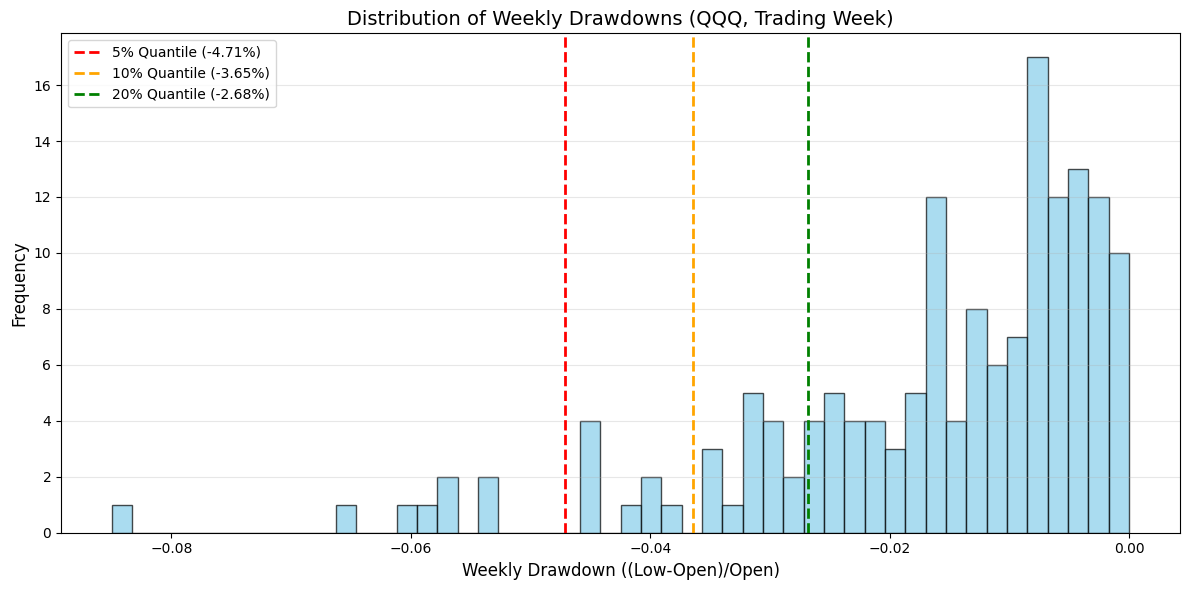

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ================= 配置区域 =================
DAILY_STOCK_FILE = 'QQQ_2023-01-01_to_2026-1-1.csv'
# ===========================================

def analyze_drawdown_distribution_v3():
    print("🔍 正在分析历史回撤分布（交易周 + (Low-Open)/Open）...")

    # 1. 读取数据
    df = pd.read_csv(DAILY_STOCK_FILE)
    if 'Datetime' in df.columns:
        df.rename(columns={'Datetime': 'Date'}, inplace=True)
    elif 'date' in df.columns:
        df.rename(columns={'date': 'Date'}, inplace=True)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

    # 2. 重采样为交易周（周五结束）
    weekly = df.resample('W-FRI').agg({
        'Open': 'first',
        'High': 'max',
        'Low': 'min',
        'Close': 'last'
    }).dropna()

    # 3. 计算周度回撤
    weekly['drawdown'] = (weekly['Low'] - weekly['Open']) / weekly['Open']

    # 4. 计算分位数阈值
    quantiles = [0.05, 0.10, 0.20]
    thresholds = {q: weekly['drawdown'].quantile(q) for q in quantiles}

    print("\n📊 历史周度最大回撤阈值 (2023-2026, 交易周, 回撤=(Low-Open)/Open):")
    print("-" * 50)
    for q, val in thresholds.items():
        print(f"   最差 {int(q*100)}% 分位数: {val:.4f} ({val:.2%})")
    print("-" * 50)

    # 5. 统计各阈值下的周数
    for q, th in thresholds.items():
        count = (weekly['drawdown'] < th).sum()
        print(f"低于 {int(q*100)}% 分位数阈值 ({th:.2%}) 的周数: {count} / {len(weekly)} ({count/len(weekly):.1%})")

    # 6. 绘图：直方图 + 三条竖线
    plt.figure(figsize=(12, 6))
    plt.hist(weekly['drawdown'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    plt.title('Distribution of Weekly Drawdowns (QQQ, Trading Week)', fontsize=14)
    plt.xlabel('Weekly Drawdown ((Low-Open)/Open)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)

    colors = {0.05: 'red', 0.10: 'orange', 0.20: 'green'}
    labels = {0.05: '5% Quantile', 0.10: '10% Quantile', 0.20: '20% Quantile'}
    for q, th in thresholds.items():
        plt.axvline(th, color=colors[q], linestyle='dashed', linewidth=2, label=f'{labels[q]} ({th:.2%})')

    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    analyze_drawdown_distribution_v3()

20%分位数阈值：-2.68%

In [ ]:
import pandas as pd
import numpy as np

# ================= 配置区域 =================
SENTIMENT_FILE = 'step5_weekly_final.csv'
DAILY_STOCK_FILE = 'QQQ_2023-01-01_to_2026-1-1.csv'
OUTPUT_FILE = 'step6_labeled_data_20pct.csv'

# 关键参数（20%分位数阈值，基于交易周 + (Low-Open)/Open 计算得出）
DRAWDOWN_THRESHOLD = -0.0268   # -2.68%
# ===========================================

def create_final_dataset():
    print(f"🏗️ 正在构建最终数据集 (阈值设定为 {DRAWDOWN_THRESHOLD:.2%})...")

    # 1. 读取情感数据（自然周周日结束）
    df_sent = pd.read_csv(SENTIMENT_FILE)
    df_sent['week_end_date'] = pd.to_datetime(df_sent['week_end_date'])
    print(f"✅ 加载情感数据: {len(df_sent)} 周")

    # 2. 读取日频数据
    try:
        df_daily = pd.read_csv(DAILY_STOCK_FILE, skiprows=1, names=['Datetime', 'Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close'])
        df_daily['Datetime'] = pd.to_datetime(df_daily['Datetime'])
        df_daily.set_index('Datetime', inplace=True)
    except:
        df_daily = pd.read_csv(DAILY_STOCK_FILE)
        df_daily['Date'] = pd.to_datetime(df_daily['Date'])
        df_daily.set_index('Date', inplace=True)

    # 3. 重采样为交易周（周五结束），提取开盘价、最高价、最低价
    weekly = df_daily.resample('W-FRI').agg({
        'Open': 'first',
        'High': 'max',
        'Low': 'min',
        'Close': 'last'
    }).dropna()

    # 4. 计算周度回撤（定义2：从开盘价到最低点的跌幅）
    weekly['drawdown'] = (weekly['Low'] - weekly['Open']) / weekly['Open']

    # 5. 生成标签：本周的情绪预测下周的回撤是否超过阈值
    weekly['next_week_risk'] = (weekly['drawdown'].shift(-1) < DRAWDOWN_THRESHOLD).astype(int)

    # 6. 将情绪数据的自然周周日回滚到当周周五，以便与交易周对齐
    print("⏰ 正在将日期从自然周(周日)回滚到交易周(周五)...")
    df_sent['week_end_date_trading'] = df_sent['week_end_date'] - pd.Timedelta(days=2)

    # 7. 合并情绪数据与标签（按回滚后的周五日期）
    df_final = pd.merge(
        df_sent,
        weekly[['next_week_risk']],
        left_on='week_end_date_trading',
        right_index=True,
        how='inner'
    )

    # 8. 清理并保存
    df_final.dropna(subset=['next_week_risk'], inplace=True)
    df_final['next_week_risk'] = df_final['next_week_risk'].astype(int)

    # 可选：保留原始周日日期和交易日周五日期
    df_final.rename(columns={'week_end_date': 'week_end_date_sun'}, inplace=True)
    df_final.rename(columns={'week_end_date_trading': 'week_end_date'}, inplace=True)

    df_final.to_csv(OUTPUT_FILE, index=False)
    print(f"✅ 数据集已生成: {OUTPUT_FILE}")

    # 9. 数据分布检查
    total = len(df_final)
    risk_count = df_final['next_week_risk'].sum()
    safe_count = total - risk_count
    print(f"\n📊 数据集统计:")
    print(f"   总样本数: {total}")
    print(f"   风险样本 (1): {risk_count} ({risk_count/total*100:.1f}%)")
    print(f"   安全样本 (0): {safe_count} ({safe_count/total*100:.1f}%)")

    # 验证日期是否为周五
    print(f"\n📅 日期验证 (合并后的 week_end_date 应为周五):")
    print(f"   前5行日期: {df_final['week_end_date'].head().tolist()}")
    print(f"   前5行星期: {df_final['week_end_date'].head().dt.day_name().tolist()}")

if __name__ == "__main__":
    create_final_dataset()

🏗️ 正在构建最终数据集 (阈值设定为 -2.68%)...
✅ 加载情感数据: 158 周
⏰ 正在将日期从自然周(周日)回滚到交易周(周五)...
✅ 数据集已生成: step6_labeled_data_20pct.csv

📊 数据集统计:
   总样本数: 157
   风险样本 (1): 31 (19.7%)
   安全样本 (0): 126 (80.3%)

📅 日期验证 (合并后的 week_end_date 应为周五):
   前5行日期: [Timestamp('2023-01-06 00:00:00'), Timestamp('2023-01-13 00:00:00'), Timestamp('2023-01-20 00:00:00'), Timestamp('2023-01-27 00:00:00'), Timestamp('2023-02-03 00:00:00')]
   前5行星期: ['Friday', 'Friday', 'Friday', 'Friday', 'Friday']


周度价格

In [ ]:
import pandas as pd
import os

# ================= 配置区域 =================
INPUT_FILE = 'QQQ_2023-01-01_to_2026-1-1.csv'
OUTPUT_FILE = 'weekly_price_data.csv'
# ============================================

def generate_weekly_prices():
    if not os.path.exists(INPUT_FILE):
        print(f"❌ 错误：找不到文件 {INPUT_FILE}")
        return

    print(f"📂 正在读取日线数据: {INPUT_FILE} ...")
    df = pd.read_csv(INPUT_FILE)

    # 修正点：根据报错信息，你的源文件日期列名为 'Datetime'
    # 我们将其转换为 datetime 对象
    df['Datetime'] = pd.to_datetime(df['Datetime'])

    # 为了方便后续合并，我们在这里就把列名重命名为 'Date'
    df.rename(columns={'Datetime': 'Date'}, inplace=True)

    # 设置日期为索引
    df.set_index('Date', inplace=True)

    print("🔄 正在进行周度聚合 (以周五为周结束)...")

    # 重采样
    weekly_df = df.resample('W-FRI').agg({
        'Open': 'first',   # 本周第一个开盘价
        'High': 'max',     # 本周最高价
        'Low': 'min',      # 本周最低价
        'Close': 'last',   # 本周最后一个收盘价
        'Volume': 'sum'    # 本周总成交量
    })

    # 删除空行
    weekly_df.dropna(inplace=True)

    # 重置索引
    weekly_df.reset_index(inplace=True)

    # 保存
    weekly_df.to_csv(OUTPUT_FILE, index=False)

    print(f"✅ 周度数据生成成功！")
    print(f"💾 已保存至: {OUTPUT_FILE}")
    print(f"📊 数据概览:")
    print(weekly_df.head())
    print(f"📅 日期范围: {weekly_df['Date'].min()} 到 {weekly_df['Date'].max()}")

if __name__ == "__main__":
    generate_weekly_prices()

📂 正在读取日线数据: QQQ_2023-01-01_to_2026-1-1.csv ...
🔄 正在进行周度聚合 (以周五为周结束)...
✅ 周度数据生成成功！
💾 已保存至: weekly_price_data.csv
📊 数据概览:
        Date        Open        High         Low       Close     Volume
0 2023-01-06  268.649994  270.149994  260.339996  268.799988  190146600
1 2023-01-13  270.829987  281.220001  268.970001  280.970001  230296400
2 2023-01-20  280.769989  284.690002  273.890015  282.679993  188788200
3 2023-01-27  283.540009  298.260010  281.179993  296.260010  256585200
4 2023-02-03  292.929993  313.679993  289.890015  306.179993  322914500
📅 日期范围: 2023-01-06 00:00:00 到 2026-01-02 00:00:00


周度价格与情绪表的合并--step7_merged_base（阈值设定为 -2.68%）

In [ ]:
import pandas as pd
import os

# ================= 配置区域 =================
WEEKLY_PRICE_FILE = 'weekly_price_data.csv'
STEP6_FILE = 'step6_labeled_data_20pct.csv'   # 修改此处
OUTPUT_FILE = 'step7_merged_20pct.csv'
# ============================================

def merge_base_data():
    print("🚀 开始 Step 7 - 第一部分：数据合并...")

    # 1. 读取周度股价数据
    print(f"📂 正在读取股价数据: {WEEKLY_PRICE_FILE}")
    df_price = pd.read_csv(WEEKLY_PRICE_FILE)
    price_date_col = 'Date' if 'Date' in df_price.columns else 'Datetime'
    df_price['Date'] = pd.to_datetime(df_price[price_date_col])

    # 2. 读取 Step 6 情绪标签数据
    print(f"📂 正在读取情绪数据: {STEP6_FILE}")
    df_sent = pd.read_csv(STEP6_FILE)
    df_sent['Date'] = pd.to_datetime(df_sent['week_end_date'])

    # 3. 数据合并
    print("🔗 正在按周对齐数据 (Inner Join)...")
    df_merged = pd.merge(df_price, df_sent, on='Date', how='inner')

    # 4. 排序与清洗
    df_merged.sort_values('Date', inplace=True)
    df_merged.reset_index(drop=True, inplace=True)

    # 5. 检查缺失值
    core_cols = ['Date', 'Close', 'Volume', 'sentiment_score', 'post_count', 'next_week_risk']
    existing_core_cols = [c for c in core_cols if c in df_merged.columns]
    missing_check = df_merged[existing_core_cols].isnull().sum()
    if missing_check.any():
        print("⚠️ 警告：发现以下列存在空值，正在删除对应行...")
        print(missing_check[missing_check > 0])
        df_merged.dropna(subset=existing_core_cols, inplace=True)

    # 6. 保存结果
    df_merged.to_csv(OUTPUT_FILE, index=False)
    print(f"✅ 合并完成！")
    print(f"💾 结果已保存至: {OUTPUT_FILE}")
    print(f"📊 数据形状: {df_merged.shape}")
    print(f"📅 时间跨度: {df_merged['Date'].min()} 到 {df_merged['Date'].max()}")
    print("\n📋 最终包含的列:")
    print(df_merged.columns.tolist())

    return df_merged

if __name__ == "__main__":
    df_final_base = merge_base_data()

🚀 开始 Step 7 - 第一部分：数据合并...
📂 正在读取股价数据: weekly_price_data.csv
📂 正在读取情绪数据: step6_labeled_data_20pct.csv
🔗 正在按周对齐数据 (Inner Join)...
✅ 合并完成！
💾 结果已保存至: step7_merged_20pct.csv
📊 数据形状: (157, 15)
📅 时间跨度: 2023-01-06 00:00:00 到 2026-01-02 00:00:00

📋 最终包含的列:
['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'week_id', 'sentiment_score', 'post_count', 'avg_score', 'total_comments', 'subreddit_count', 'week_end_date_sun', 'week_end_date', 'next_week_risk']


宏观数据

下载与处理 VIX 指数数据

In [ ]:
pip install yfinance pandas_datareader pandas numpy

In [ ]:
import yfinance as yf
import pandas as pd

# 下载 VIX 日度数据
vix_daily = yf.download("^VIX", start="2023-01-01", end="2026-01-01", interval="1d", progress=False, auto_adjust=False)

# 如果列名是元组（多级索引），简化为一层
if isinstance(vix_daily.columns[0], tuple):
    vix_daily.columns = [col[0] for col in vix_daily.columns]

# 只保留收盘价
vix_close = vix_daily[['Close']].copy()

# 重采样为周五结束的交易周
vix_weekly = vix_close.resample('W-FRI').last()

# 计算指标
close_series = vix_weekly['Close']
vix_weekly['VIX_MA20'] = close_series.rolling(20, min_periods=20).mean()
vix_weekly['VIX_Trend'] = close_series - vix_weekly['VIX_MA20']

# 保存结果
vix_weekly[['VIX_Trend']].to_csv('vix_trading_week.csv')
print(vix_weekly[['VIX_Trend']].head())

            VIX_Trend
Date                 
2023-01-06        NaN
2023-01-13        NaN
2023-01-20        NaN
2023-01-27        NaN
2023-02-03        NaN


下载与处理国债收益率数据

In [ ]:
from pandas_datareader import data as pdr

# 1. 定义获取数据的函数
def get_fred_data(series_id, start_date, end_date):
    try:
        data = pdr.DataReader(series_id, 'fred', start_date, end_date)
        return data
    except Exception as e:
        print(f"获取数据失败 {series_id}: {e}")
        return None

# 2. 下载 10年期和2年期国债收益率日度数据
start = "2022-12-31"
end = "2026-01-01"

print("Downloading DGS10 and DGS2 data from FRED...")
dgs10_daily = get_fred_data('DGS10', start, end)
dgs2_daily = get_fred_data('DGS2', start, end)

# 3. 查看下载的数据
print("\n10-Year Treasury Yield (DGS10) Head:")
print(dgs10_daily.head())


10-Year Treasury Yield (DGS10) Head:
            DGS10
DATE             
2023-01-02    NaN
2023-01-03   3.79
2023-01-04   3.69
2023-01-05   3.71
2023-01-06   3.55


将国债数据转换为周度


In [ ]:
# 1. 检查数据索引的时区并调整，这是与 VIX 周数据对齐的关键一步
if dgs10_daily is not None and dgs2_daily is not None:
    # 确保索引是时区无关的，以便与 yfinance 的数据对齐
    dgs10_daily.index = dgs10_daily.index.tz_localize(None)
    dgs2_daily.index = dgs2_daily.index.tz_localize(None)

    # 2. 合并10年期和2年期数据
    yields_daily = pd.DataFrame({
        'dgs10': dgs10_daily['DGS10'],
        'dgs2': dgs2_daily['DGS2']
    }).dropna()  # 删除任何一列有空缺的行

    # 3. 定义重采样规则：以周五为结束日，取每周的最后一个有效值
    yields_weekly = yields_daily.resample('W-FRI').last()

    # 4. 计算每周的债券利差 (10年期 - 2年期)
    yields_weekly['yield_spread'] = yields_weekly['dgs10'] - yields_weekly['dgs2']

    print("\nProcessed Weekly Treasury Data (with Spread):")
    print(yields_weekly.head())
else:
    print("Failed to download treasury data. Please check your connection and FRED API key if using one.")


Processed Weekly Treasury Data (with Spread):
            dgs10  dgs2  yield_spread
DATE                                 
2023-01-06   3.55  4.24         -0.69
2023-01-13   3.49  4.22         -0.73
2023-01-20   3.48  4.14         -0.66
2023-01-27   3.52  4.19         -0.67
2023-02-03   3.53  4.30         -0.77


保存处理好的数据

In [ ]:
#保存国债收益率周度数据
yields_weekly.to_csv('treasury_weekly.csv')
print("Saved Treasury weekly data to 'treasury_weekly.csv'")

Saved Treasury weekly data to 'treasury_weekly.csv'


合并宏观数据和基础数据（阈值设定：-2.68%）

In [ ]:
import pandas as pd

# 1. 读取宏观指标
vix = pd.read_csv('vix_trading_week.csv', index_col='Date', parse_dates=True)  # 索引应为 'Date'
treasury = pd.read_csv('treasury_weekly.csv', index_col='DATE', parse_dates=True)  # 索引为 'DATE'

# 2. 合并宏观指标
macro = vix.join(treasury[['yield_spread']], how='inner')
print(f"宏观数据行数: {len(macro)}")

# 3. 读取基础数据（新生成的 step7_merged_base.csv，包含正确标签）
base = pd.read_csv('step7_merged_20pct.csv', parse_dates=['Date'])  # 日期列名为 'Date'

# 4. 合并（左连接，保留基础数据所有行）
final = base.merge(macro, left_on='Date', right_index=True, how='left')

# 5. 检查
print(f"合并后总行数: {len(final)}")
print(final.head())
print("缺失宏观指标的行数:", final['VIX_Trend'].isna().sum())

# 6. 保存为新文件（避免覆盖旧数据）
final.to_csv('final_combined_base_20pct.csv', index=False)
print("✅ 已保存 final_combined_base_20pct.csv")

宏观数据行数: 157
合并后总行数: 157
        Date        Open        High         Low       Close     Volume  \
0 2023-01-06  268.649994  270.149994  260.339996  268.799988  190146600   
1 2023-01-13  270.829987  281.220001  268.970001  280.970001  230296400   
2 2023-01-20  280.769989  284.690002  273.890015  282.679993  188788200   
3 2023-01-27  283.540009  298.260010  281.179993  296.260010  256585200   
4 2023-02-03  292.929993  313.679993  289.890015  306.179993  322914500   

                 week_id  sentiment_score  post_count    avg_score  \
0  2023-01-02/2023-01-08         0.400768           6    91.333333   
1  2023-01-09/2023-01-15         0.648723           5  1063.800000   
2  2023-01-16/2023-01-22         0.675320          17    99.529412   
3  2023-01-23/2023-01-29         0.546256           8    60.250000   
4  2023-01-30/2023-02-05         0.406467          11   353.909091   

   total_comments  subreddit_count week_end_date_sun week_end_date  \
0             253                3

第一阶段：逻辑回归五组实验（A1~A5）
目的：确定情绪因素在逻辑回归中的独立贡献，并选出最佳特征组合。

统一设置：

模型：逻辑回归（L2正则化，C=0.1，class_weight='balanced'）

滚动窗口：训练100周，测试1周，步长1周，共57次预测

评估指标：召回率（Recall）、F1、AUC

实验编号	特征组合	特征列表	目的

EP1	仅技术指标	['MA_Bias', 'ATR', 'RSI', 'Volume_Change']	基准线

EP2	情绪指标	['Sentiment_Level', 'Sentiment_Uncertainty', 'Volume_Spike'] +情绪与价格的背离Price_Sentiment_Divergence	情绪预测能力

EP3  技术指标 + 情绪指标 + 宏观指标 + Price_Sentiment_Divergence+Risk Resonance（情绪与宏观共振）


固定阈值0.5

In [ ]:
# ==================== 第一部分：数据加载与预处理 ====================
import pandas as pd
import numpy as np

print("="*50)
print("第一部分：数据加载与预处理 (20% 阈值)")
print("="*50)

# 读取合并后的数据（20% 阈值文件，请确保文件名不含百分号，建议重命名为 'final_combined_base_20pct.csv'）
df = pd.read_csv('final_combined_base_20pct.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# 检查数据完整性
print(f"1. 总样本数: {len(df)}")
print(f"2. 日期范围: {df['Date'].min()} 到 {df['Date'].max()}")
print(f"3. VIX_Trend 缺失数: {df['VIX_Trend'].isna().sum()}")
print(f"4. yield_spread 缺失数: {df['yield_spread'].isna().sum()}")
print(f"5. next_week_risk 正例比例: {df['next_week_risk'].mean():.2%}")

# 滚动参数
TRAIN_WINDOW = 100
TOTAL_WEEKS = len(df)
print(f"6. 滚动窗口参数: 训练集大小 = {TRAIN_WINDOW} 周, 总样本 = {TOTAL_WEEKS} 周")
print(f"7. 预计滚动预测次数: {TOTAL_WEEKS - TRAIN_WINDOW} 次")

# 特征分组
tech_features = ['MA_Bias', 'ATR', 'RSI', 'Volume_Change']
sentiment_features = ['Sentiment_Level', 'Sentiment_Uncertainty', 'Volume_Spike']
macro_features = ['VIX_Trend', 'yield_spread']
divergence_feature = ['Price_Sentiment_Divergence']
resonance_feature = ['Risk_Resonance']

# 实验定义（三个）
experiments = {
    'Exp1_tech': tech_features,
    'Exp2_tech_sent_div': tech_features + sentiment_features + divergence_feature,
    'Exp3_all_with_div_res': tech_features + sentiment_features + macro_features + divergence_feature + resonance_feature
}

print("\n实验特征组合:")
for name, feats in experiments.items():
    print(f"  {name}: {len(feats)} 个特征")
print("第一部分完成。\n")

# ==================== 第二部分：特征计算函数定义 ====================
print("="*50)
print("第二部分：特征计算函数定义及测试")
print("="*50)

def add_technical_indicators(win_df):
    """计算技术指标（只使用历史数据）"""
    df_win = win_df.copy()
    df_win['MA20'] = df_win['Close'].rolling(20, min_periods=1).mean()
    df_win['MA_Bias'] = (df_win['Close'] - df_win['MA20']) / df_win['MA20']
    df_win['TR'] = df_win['High'] - df_win['Low']
    df_win['ATR'] = df_win['TR'].rolling(14, min_periods=1).mean()
    delta = df_win['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(14, min_periods=1).mean()
    avg_loss = loss.rolling(14, min_periods=1).mean()
    rs = avg_gain / avg_loss
    df_win['RSI'] = 100 - (100 / (1 + rs))
    df_win['Volume_Change'] = df_win['Volume'].pct_change()
    return df_win

def add_sentiment_indicators(win_df):
    """计算情绪派生指标"""
    df_win = win_df.copy()
    df_win['Sentiment_Level'] = df_win['sentiment_score']
    df_win['Sentiment_Uncertainty'] = df_win['sentiment_score'].rolling(4, min_periods=1).std()
    df_win['Volume_Spike'] = df_win['post_count'] / df_win['post_count'].rolling(4, min_periods=1).mean()
    df_win['Volume_Spike'] = df_win['Volume_Spike'].clip(upper=5)
    return df_win

def add_divergence_feature(win_df):
    """计算价格-情绪背离 (Price_Sentiment_Divergence)"""
    df_win = win_df.copy()
    price_dir = np.sign(df_win['Close'].diff())
    sentiment_dir = np.sign(df_win['sentiment_score'].diff())
    df_win['Price_Sentiment_Divergence'] = (price_dir * sentiment_dir == -1).astype(int)
    df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)
    return df_win

def add_risk_resonance(win_df):
    """计算风险共振 (Risk_Resonance)"""
    df_win = win_df.copy()
    # 情绪不确定性的4周中位数
    uncertainty_median = df_win['Sentiment_Uncertainty'].rolling(4, min_periods=1).median()
    # 共振条件：不确定性 > 中位数 且 VIX_Trend > 0
    df_win['Risk_Resonance'] = ((df_win['Sentiment_Uncertainty'] > uncertainty_median) & (df_win['VIX_Trend'] > 0)).astype(int)
    return df_win

# 测试特征计算函数（仅验证）
test_df = df.iloc[:100].copy()
test_with_tech = add_technical_indicators(test_df)
test_with_sent = add_sentiment_indicators(test_with_tech)
test_with_div = add_divergence_feature(test_with_sent)
test_with_res = add_risk_resonance(test_with_div)
print("特征计算函数测试（前100周）:")
print(f"  生成的技术指标列: {[col for col in test_with_tech.columns if col in tech_features]}")
print(f"  生成的情绪指标列: {[col for col in test_with_sent.columns if col in sentiment_features]}")
print(f"  生成的背离特征列: {'Price_Sentiment_Divergence' in test_with_div.columns}")
print(f"  生成的共振特征列: {'Risk_Resonance' in test_with_res.columns}")
print("第二部分完成。\n")

# ==================== 第三部分：滚动窗口训练与预测（三个实验） ====================
print("="*50)
print("第三部分：滚动窗口训练与预测（三个实验）")
print("="*50)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 存储所有实验结果
all_results = {name: [] for name in experiments.keys()}

total_iters = TOTAL_WEEKS - TRAIN_WINDOW
print(f"滚动窗口总迭代次数: {total_iters}\n")

for i, test_idx in enumerate(range(TRAIN_WINDOW, TOTAL_WEEKS)):
    # 提取原始数据
    train_raw = df.iloc[test_idx - TRAIN_WINDOW : test_idx]
    test_raw = df.iloc[test_idx : test_idx+1]
    window_raw = pd.concat([train_raw, test_raw], axis=0).reset_index(drop=True)

    # 计算所有派生特征（技术 + 情绪 + 背离 + 共振）
    window_feat = add_technical_indicators(window_raw)
    window_feat = add_sentiment_indicators(window_feat)
    window_feat = add_divergence_feature(window_feat)
    window_feat = add_risk_resonance(window_feat)

    # 分割训练集和测试集
    X_train_full = window_feat.iloc[:-1]
    X_test = window_feat.iloc[-1:]
    y_train = X_train_full['next_week_risk'].values
    y_test = X_test['next_week_risk'].values[0]

    # 对三个实验分别训练
    for exp_name, features in experiments.items():
        # 训练集特征
        X_train = X_train_full[features].dropna()
        if len(X_train) < 50:
            continue
        train_idx = X_train.index
        y_train_aligned = y_train[train_idx]

        # 测试集特征
        X_test_feat = X_test[features].dropna()
        if len(X_test_feat) == 0:
            continue

        # 模型训练
        model = make_pipeline(
            StandardScaler(),
            LogisticRegression(penalty='l2', C=0.1, class_weight='balanced', max_iter=1000)
        )
        model.fit(X_train, y_train_aligned)
        y_pred = model.predict(X_test_feat)[0]
        y_prob = model.predict_proba(X_test_feat)[0][1]

        all_results[exp_name].append({
            'test_date': X_test['Date'].values[0],
            'true_label': y_test,
            'pred_label': y_pred,
            'prob': y_prob
        })

    # 每10次打印进度
    if (i+1) % 10 == 0:
        print(f"  已完成 {i+1}/{total_iters} 次迭代")

print("滚动循环结束。")
for exp_name in experiments.keys():
    print(f"  {exp_name} 有效预测次数: {len(all_results[exp_name])}")
print("第三部分完成。\n")

# ==================== 第四部分：结果评估与保存 ====================
print("="*50)
print("第四部分：结果评估与保存")
print("="*50)

from sklearn.metrics import recall_score, f1_score, roc_auc_score

print("\n===== 三个实验的滚动窗口验证结果 (20% 阈值) =====")
for exp_name in experiments.keys():
    df_res = pd.DataFrame(all_results[exp_name])
    if len(df_res) == 0:
        print(f"{exp_name}: 无有效预测")
        continue
    recall = recall_score(df_res['true_label'], df_res['pred_label'])
    f1 = f1_score(df_res['true_label'], df_res['pred_label'])
    auc = roc_auc_score(df_res['true_label'], df_res['prob'])
    print(f"{exp_name} - 预测次数: {len(df_res)}, Recall: {recall:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
    # 保存详细结果
    df_res.to_csv(f'{exp_name}_20pct_predictions.csv', index=False)
    print(f"  已保存预测结果到 {exp_name}_20pct_predictions.csv")

print("\n全部实验完成！")

第一部分：数据加载与预处理 (20% 阈值)
1. 总样本数: 157
2. 日期范围: 2023-01-06 00:00:00 到 2026-01-02 00:00:00
3. VIX_Trend 缺失数: 19
4. yield_spread 缺失数: 0
5. next_week_risk 正例比例: 19.75%
6. 滚动窗口参数: 训练集大小 = 100 周, 总样本 = 157 周
7. 预计滚动预测次数: 57 次

实验特征组合:
  Exp1_tech: 4 个特征
  Exp2_tech_sent_div: 8 个特征
  Exp3_all_with_div_res: 11 个特征
第一部分完成。

第二部分：特征计算函数定义及测试
特征计算函数测试（前100周）:
  生成的技术指标列: ['MA_Bias', 'ATR', 'RSI', 'Volume_Change']
  生成的情绪指标列: ['Sentiment_Level', 'Sentiment_Uncertainty', 'Volume_Spike']
  生成的背离特征列: True
  生成的共振特征列: True
第二部分完成。

第三部分：滚动窗口训练与预测（三个实验）


/tmp/ipykernel_4711/2019535465.py:82: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)


滚动窗口总迭代次数: 57



/tmp/ipykernel_4711/2019535465.py:82: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)
/tmp/ipykernel_4711/2019535465.py:82: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

  已完成 10/57 次迭代


...

  已完成 40/57 次迭代


/tmp/ipykernel_4711/2019535465.py:82: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)
/tmp/ipykernel_4711/2019535465.py:82: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

  已完成 50/57 次迭代


/tmp/ipykernel_4711/2019535465.py:82: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)
/tmp/ipykernel_4711/2019535465.py:82: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

滚动循环结束。
  Exp1_tech 有效预测次数: 57
  Exp2_tech_sent_div 有效预测次数: 57
  Exp3_all_with_div_res 有效预测次数: 57
第三部分完成。

第四部分：结果评估与保存

===== 三个实验的滚动窗口验证结果 (20% 阈值) =====
Exp1_tech - 预测次数: 57, Recall: 0.5333, F1: 0.4000, AUC: 0.6190
  已保存预测结果到 Exp1_tech_20pct_predictions.csv
Exp2_tech_sent_div - 预测次数: 57, Recall: 0.6667, F1: 0.4348, AUC: 0.6095
  已保存预测结果到 Exp2_tech_sent_div_20pct_predictions.csv
Exp3_all_with_div_res - 预测次数: 57, Recall: 0.6667, F1: 0.4255, AUC: 0.6460
  已保存预测结果到 Exp3_all_with_div_res_20pct_predictions.csv

全部实验完成！


成本阈值法：

In [1]:
# ==================== 第一步：特征对比实验（成本法阈值 + 复合指标） ====================
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import recall_score, roc_auc_score

print("="*60)
print("第一步：特征对比实验（成本法阈值，复合指标 = Recall × AUC）")
print("逻辑回归 C=0.1（默认），滚动窗口100周，成本法阈值 (FN=10, FP=1)")
print("="*60)

# -------------------- 1. 数据加载 --------------------
df = pd.read_csv('final_combined_base_20pct.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"总样本数: {len(df)}")
print(f"正例比例: {df['next_week_risk'].mean():.2%}")

# -------------------- 2. 滚动参数 --------------------
TRAIN_WINDOW = 100
TOTAL_WEEKS = len(df)
COST_FN = 10.0
COST_FP = 1.0

# -------------------- 3. 特征计算函数（同前） --------------------
def add_technical_indicators(win_df):
    df_win = win_df.copy()
    df_win['MA20'] = df_win['Close'].rolling(20, min_periods=1).mean()
    df_win['MA_Bias'] = (df_win['Close'] - df_win['MA20']) / df_win['MA20']
    df_win['TR'] = df_win['High'] - df_win['Low']
    df_win['ATR'] = df_win['TR'].rolling(14, min_periods=1).mean()
    delta = df_win['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(14, min_periods=1).mean()
    avg_loss = loss.rolling(14, min_periods=1).mean()
    rs = avg_gain / avg_loss
    df_win['RSI'] = 100 - (100 / (1 + rs))
    df_win['Volume_Change'] = df_win['Volume'].pct_change()
    return df_win

def add_sentiment_indicators(win_df):
    df_win = win_df.copy()
    df_win['Sentiment_Level'] = df_win['sentiment_score']
    df_win['Sentiment_Uncertainty'] = df_win['sentiment_score'].rolling(4, min_periods=1).std()
    df_win['Volume_Spike'] = df_win['post_count'] / df_win['post_count'].rolling(4, min_periods=1).mean()
    df_win['Volume_Spike'] = df_win['Volume_Spike'].clip(upper=5)
    return df_win

def add_divergence_feature(win_df):
    df_win = win_df.copy()
    price_dir = np.sign(df_win['Close'].diff())
    sentiment_dir = np.sign(df_win['sentiment_score'].diff())
    df_win['Price_Sentiment_Divergence'] = (price_dir * sentiment_dir == -1).astype(int)
    df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)
    return df_win

def add_risk_resonance(win_df):
    df_win = win_df.copy()
    uncertainty_median = df_win['Sentiment_Uncertainty'].rolling(4, min_periods=1).median()
    df_win['Risk_Resonance'] = ((df_win['Sentiment_Uncertainty'] > uncertainty_median) & (df_win['VIX_Trend'] > 0)).astype(int)
    return df_win

# 计算所有特征（一次计算，多次使用）
df_feat = add_technical_indicators(df)
df_feat = add_sentiment_indicators(df_feat)
df_feat = add_divergence_feature(df_feat)
df_feat = add_risk_resonance(df_feat)

# 特征分组（与用户代码一致）
tech_features = ['MA_Bias', 'ATR', 'RSI', 'Volume_Change']
sentiment_features = ['Sentiment_Level', 'Sentiment_Uncertainty', 'Volume_Spike']
macro_features = ['VIX_Trend', 'yield_spread']
divergence_feature = ['Price_Sentiment_Divergence']
resonance_feature = ['Risk_Resonance']

experiments = {
    'Exp1_tech': tech_features,
    'Exp2_tech_sent_div': tech_features + sentiment_features + divergence_feature,
    'Exp3_all_with_div_res': tech_features + sentiment_features + macro_features + divergence_feature + resonance_feature
}

# -------------------- 4. 滚动窗口 + 成本法阈值评估函数 --------------------
def evaluate_cost_sensitive_for_exp(feature_list):
    """对单个特征列表进行滚动窗口成本法评估，返回全局召回率、AUC和复合得分"""
    all_true = []
    all_prob = []
    all_pred = []
    for test_idx in range(TRAIN_WINDOW, TOTAL_WEEKS):
        # 取窗口数据（从原始特征矩阵中切片，避免重复计算）
        train_raw = df_feat.iloc[test_idx - TRAIN_WINDOW : test_idx]
        test_raw = df_feat.iloc[test_idx : test_idx+1]
        y_train_raw = df_feat['next_week_risk'].iloc[test_idx - TRAIN_WINDOW : test_idx]
        y_test = df_feat['next_week_risk'].iloc[test_idx]

        # 选取特征列
        X_train = train_raw[feature_list].dropna()
        y_train = y_train_raw.loc[X_train.index]
        if len(X_train) < 50:
            continue

        X_test = test_raw[feature_list].dropna()
        if len(X_test) == 0:
            continue

        # 划分验证集（最后20%）
        split = int(len(X_train) * 0.8)
        X_tr, X_val = X_train.iloc[:split], X_train.iloc[split:]
        y_tr, y_val = y_train.iloc[:split], y_train.iloc[split:]

        # 训练逻辑回归（C=0.1，固定）
        model = make_pipeline(StandardScaler(),
                              LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000))
        model.fit(X_tr, y_tr)

        # 验证集概率
        probs_val = model.predict_proba(X_val)[:, 1]

        # 成本法搜索最优阈值
        best_thr = 0.5
        min_cost = float('inf')
        for thr in np.arange(0.1, 0.6, 0.01):
            pred_val = (probs_val >= thr).astype(int)
            fn = np.sum((y_val == 1) & (pred_val == 0))
            fp = np.sum((y_val == 0) & (pred_val == 1))
            cost = COST_FN * fn + COST_FP * fp
            if cost < min_cost:
                min_cost = cost
                best_thr = thr

        # 测试集预测
        prob_test = model.predict_proba(X_test)[0][1]
        pred_test = (prob_test >= best_thr).astype(int)

        all_true.append(y_test)
        all_prob.append(prob_test)
        all_pred.append(pred_test)

    if len(all_true) == 0:
        return 0, 0, 0
    recall = recall_score(all_true, all_pred)
    auc = roc_auc_score(all_true, all_prob)
    composite = recall * auc
    return recall, auc, composite

# -------------------- 5. 执行三个实验 --------------------
print("\n开始特征对比实验（成本法阈值）...\n")
for name, feature_list in experiments.items():
    recall, auc, composite = evaluate_cost_sensitive_for_exp(feature_list)
    print(f"{name}: Recall = {recall:.4f}, AUC = {auc:.4f}, Composite = {composite:.4f}")

print("\n特征对比实验完成。")

第一步：特征对比实验（成本法阈值，复合指标 = Recall × AUC）
逻辑回归 C=0.1（默认），滚动窗口100周，成本法阈值 (FN=10, FP=1)
总样本数: 157
正例比例: 19.75%

开始特征对比实验（成本法阈值）...



/tmp/ipykernel_8203/2523254459.py:57: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)


Exp1_tech: Recall = 0.8667, AUC = 0.5540, Composite = 0.4801
Exp2_tech_sent_div: Recall = 0.8000, AUC = 0.5714, Composite = 0.4571
Exp3_all_with_div_res: Recall = 0.8000, AUC = 0.6048, Composite = 0.4838

特征对比实验完成。


# **三个模型独立调参与比较（成本阈值法）**

成本法阈值调优（FN=10, FP=1）

复合指标

logestic regression

In [ ]:
# ==================== 完整代码：20%阈值 + 实验三 + 成本法阈值调优（以 Recall×AUC 为评判标准） ====================
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import recall_score, f1_score, roc_auc_score

print("="*60)
print("20% 阈值 | 实验三: 技术+情绪+宏观+背离+共振 | 成本法阈值 (FN=10, FP=1)")
print("评判标准: 复合得分 = Recall × AUC")
print("="*60)

# -------------------- 1. 数据加载 --------------------
df = pd.read_csv('final_combined_base_20pct.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"总样本数: {len(df)}")
print(f"日期范围: {df['Date'].min()} 至 {df['Date'].max()}")
print(f"VIX_Trend 缺失数: {df['VIX_Trend'].isna().sum()}")
print(f"yield_spread 缺失数: {df['yield_spread'].isna().sum()}")
print(f"正例比例: {df['next_week_risk'].mean():.2%}")

# -------------------- 2. 滚动参数 --------------------
TRAIN_WINDOW = 100
TOTAL_WEEKS = len(df)
print(f"训练窗口: {TRAIN_WINDOW} 周, 总周数: {TOTAL_WEEKS}, 预测次数: {TOTAL_WEEKS - TRAIN_WINDOW}")

# -------------------- 3. 特征计算函数 --------------------
def add_technical_indicators(win_df):
    df_win = win_df.copy()
    df_win['MA20'] = df_win['Close'].rolling(20, min_periods=1).mean()
    df_win['MA_Bias'] = (df_win['Close'] - df_win['MA20']) / df_win['MA20']
    df_win['TR'] = df_win['High'] - df_win['Low']
    df_win['ATR'] = df_win['TR'].rolling(14, min_periods=1).mean()
    delta = df_win['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(14, min_periods=1).mean()
    avg_loss = loss.rolling(14, min_periods=1).mean()
    rs = avg_gain / avg_loss
    df_win['RSI'] = 100 - (100 / (1 + rs))
    df_win['Volume_Change'] = df_win['Volume'].pct_change()
    return df_win

def add_sentiment_indicators(win_df):
    df_win = win_df.copy()
    df_win['Sentiment_Level'] = df_win['sentiment_score']
    df_win['Sentiment_Uncertainty'] = df_win['sentiment_score'].rolling(4, min_periods=1).std()
    df_win['Volume_Spike'] = df_win['post_count'] / df_win['post_count'].rolling(4, min_periods=1).mean()
    df_win['Volume_Spike'] = df_win['Volume_Spike'].clip(upper=5)
    return df_win

def add_divergence_feature(win_df):
    df_win = win_df.copy()
    price_dir = np.sign(df_win['Close'].diff())
    sentiment_dir = np.sign(df_win['sentiment_score'].diff())
    df_win['Price_Sentiment_Divergence'] = (price_dir * sentiment_dir == -1).astype(int)
    df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)
    return df_win

def add_risk_resonance(win_df):
    df_win = win_df.copy()
    uncertainty_median = df_win['Sentiment_Uncertainty'].rolling(4, min_periods=1).median()
    df_win['Risk_Resonance'] = ((df_win['Sentiment_Uncertainty'] > uncertainty_median) & (df_win['VIX_Trend'] > 0)).astype(int)
    return df_win

# -------------------- 4. 实验三的特征列表 --------------------
features_exp3 = [
    'MA_Bias', 'ATR', 'RSI', 'Volume_Change',
    'Sentiment_Level', 'Sentiment_Uncertainty', 'Volume_Spike',
    'VIX_Trend', 'yield_spread',
    'Price_Sentiment_Divergence', 'Risk_Resonance'
]

# -------------------- 5. 成本参数 --------------------
COST_FN = 10.0
COST_FP = 1.0

# -------------------- 6. 待搜索的 C 值列表 --------------------
C_values = [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]   # 可自行增减
results_summary = []

for C in C_values:
    print(f"\n正在测试 C = {C} ...")
    results = {'true': [], 'prob': [], 'pred': [], 'threshold': []}
    total_iters = TOTAL_WEEKS - TRAIN_WINDOW

    for test_idx in range(TRAIN_WINDOW, TOTAL_WEEKS):
        # 提取窗口
        train_raw = df.iloc[test_idx - TRAIN_WINDOW : test_idx]
        test_raw = df.iloc[test_idx : test_idx+1]
        window_raw = pd.concat([train_raw, test_raw], axis=0).reset_index(drop=True)

        # 计算所有特征
        window_feat = add_technical_indicators(window_raw)
        window_feat = add_sentiment_indicators(window_feat)
        window_feat = add_divergence_feature(window_feat)
        window_feat = add_risk_resonance(window_feat)

        X_train_full = window_feat.iloc[:-1]
        X_test = window_feat.iloc[-1:]
        y_train = X_train_full['next_week_risk'].values
        y_test = X_test['next_week_risk'].values[0]

        X_train = X_train_full[features_exp3].dropna()
        if len(X_train) < 50:
            continue
        train_idx = X_train.index
        y_train_aligned = y_train[train_idx]

        X_test_feat = X_test[features_exp3].dropna()
        if len(X_test_feat) == 0:
            continue

        # 划分验证集
        split = int(len(X_train) * 0.8)
        X_tr, X_val = X_train[:split], X_train[split:]
        y_tr, y_val = y_train_aligned[:split], y_train_aligned[split:]

        # 使用当前 C 值训练模型
        model = make_pipeline(
            StandardScaler(),
            LogisticRegression(penalty='l2', C=C, class_weight='balanced', max_iter=1000)
        )
        model.fit(X_tr, y_tr)

        probs_val = model.predict_proba(X_val)[:, 1]

        # 成本法搜索最优阈值
        best_threshold = 0.5
        min_cost = float('inf')
        for thr in np.arange(0.1, 0.6, 0.01):
            y_pred_val = (probs_val >= thr).astype(int)
            fn = np.sum((y_val == 1) & (y_pred_val == 0))
            fp = np.sum((y_val == 0) & (y_pred_val == 1))
            cost = COST_FN * fn + COST_FP * fp
            if cost < min_cost:
                min_cost = cost
                best_threshold = thr

        y_prob = model.predict_proba(X_test_feat)[0][1]
        y_pred = (y_prob >= best_threshold).astype(int)

        results['true'].append(y_test)
        results['prob'].append(y_prob)
        results['pred'].append(y_pred)
        results['threshold'].append(best_threshold)

    # 汇总指标
    df_res = pd.DataFrame(results)
    if len(df_res) == 0:
        print(f"C={C}: 无有效预测")
        continue
    recall = recall_score(df_res['true'], df_res['pred'])
    f1 = f1_score(df_res['true'], df_res['pred'])
    auc = roc_auc_score(df_res['true'], df_res['prob'])
    avg_thr = df_res['threshold'].mean()
    composite = recall * auc   # 复合得分
    results_summary.append({
        'C': C,
        'Recall': recall,
        'F1': f1,
        'AUC': auc,
        'Composite': composite,
        'Avg_Threshold': avg_thr,
        'Predictions': len(df_res)
    })
    print(f"  C={C}: Recall={recall:.4f}, AUC={auc:.4f}, Composite={composite:.4f}, Avg_Thr={avg_thr:.3f}")

# -------------------- 输出汇总表格（按复合得分排序） --------------------
print("\n" + "="*60)
print("C 值调优结果汇总（按 Composite = Recall × AUC 排序）")
print("="*60)
summary_df = pd.DataFrame(results_summary).sort_values('Composite', ascending=False)
print(summary_df.to_string(index=False))

# 找出最佳 C（以复合得分为优先）
best_row = summary_df.loc[summary_df['Composite'].idxmax()]
print(f"\n推荐 C 值: {best_row['C']} (复合得分 {best_row['Composite']:.4f}, Recall={best_row['Recall']:.4f}, AUC={best_row['AUC']:.4f})")

20% 阈值 | 实验三: 技术+情绪+宏观+背离+共振 | 成本法阈值 (FN=10, FP=1)
总样本数: 157
日期范围: 2023-01-06 00:00:00 至 2026-01-02 00:00:00
VIX_Trend 缺失数: 19
yield_spread 缺失数: 0
正例比例: 19.75%
训练窗口: 100 周, 总周数: 157, 预测次数: 57

开始滚动窗口验证（共 57 次迭代）...



/tmp/ipykernel_4711/2748172564.py:58: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)
/tmp/ipykernel_4711/2748172564.py:58: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

  已完成 10 / 57 次迭代


/tmp/ipykernel_4711/2748172564.py:58: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)
/tmp/ipykernel_4711/2748172564.py:58: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

  已完成 20 / 57 次迭代


...

/tmp/ipykernel_4711/2748172564.py:58: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)
/tmp/ipykernel_4711/2748172564.py:58: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

  已完成 50 / 57 次迭代


/tmp/ipykernel_4711/2748172564.py:58: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)
/tmp/ipykernel_4711/2748172564.py:58: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac


滚动循环结束。
有效预测次数: 57

===== 最终性能 (成本法阈值) =====
召回率 (Recall) = 0.8000
F1分数 = 0.3934
AUC = 0.6127
平均最优阈值 = 0.371

预测结果已保存至 Exp3_all_with_div_res_20pct_cost_threshold.csv


/tmp/ipykernel_4711/2748172564.py:58: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)
/tmp/ipykernel_4711/2748172564.py:58: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

random forest

In [ ]:
# ==================== 随机森林调优：20%阈值 + 实验三 + 成本法阈值 + 复合得分 ====================
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("随机森林调优 | 20% 阈值 | 实验三 (全特征) | 成本法阈值 (FN=10, FP=1)")
print("评判标准: 复合得分 = Recall × AUC")
print("="*60)

# -------------------- 1. 数据加载与特征工程 --------------------
df = pd.read_csv('final_combined_base_20pct.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

def add_technical_indicators(win_df):
    df_win = win_df.copy()
    df_win['MA20'] = df_win['Close'].rolling(20, min_periods=1).mean()
    df_win['MA_Bias'] = (df_win['Close'] - df_win['MA20']) / df_win['MA20']
    df_win['TR'] = df_win['High'] - df_win['Low']
    df_win['ATR'] = df_win['TR'].rolling(14, min_periods=1).mean()
    delta = df_win['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(14, min_periods=1).mean()
    avg_loss = loss.rolling(14, min_periods=1).mean()
    rs = avg_gain / avg_loss
    df_win['RSI'] = 100 - (100 / (1 + rs))
    df_win['Volume_Change'] = df_win['Volume'].pct_change()
    return df_win

def add_sentiment_indicators(win_df):
    df_win = win_df.copy()
    df_win['Sentiment_Level'] = df_win['sentiment_score']
    df_win['Sentiment_Uncertainty'] = df_win['sentiment_score'].rolling(4, min_periods=1).std()
    df_win['Volume_Spike'] = df_win['post_count'] / df_win['post_count'].rolling(4, min_periods=1).mean()
    df_win['Volume_Spike'] = df_win['Volume_Spike'].clip(upper=5)
    return df_win

def add_divergence_feature(win_df):
    df_win = win_df.copy()
    price_dir = np.sign(df_win['Close'].diff())
    sentiment_dir = np.sign(df_win['sentiment_score'].diff())
    df_win['Price_Sentiment_Divergence'] = (price_dir * sentiment_dir == -1).astype(int)
    df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)
    return df_win

def add_risk_resonance(win_df):
    df_win = win_df.copy()
    uncertainty_median = df_win['Sentiment_Uncertainty'].rolling(4, min_periods=1).median()
    df_win['Risk_Resonance'] = ((df_win['Sentiment_Uncertainty'] > uncertainty_median) & (df_win['VIX_Trend'] > 0)).astype(int)
    return df_win

df = add_technical_indicators(df)
df = add_sentiment_indicators(df)
df = add_divergence_feature(df)
df = add_risk_resonance(df)

features = [
    'MA_Bias', 'ATR', 'RSI', 'Volume_Change',
    'Sentiment_Level', 'Sentiment_Uncertainty', 'Volume_Spike',
    'VIX_Trend', 'yield_spread',
    'Price_Sentiment_Divergence', 'Risk_Resonance'
]
X = df[features]
y = df['next_week_risk']

# -------------------- 2. 滚动窗口参数 --------------------
TRAIN_WINDOW = 100
TOTAL_WEEKS = len(X)
COST_FN = 10
COST_FP = 1

# -------------------- 3. 成本法评估函数（适用于随机森林） --------------------
def evaluate_rf_cost_sensitive(params, X, y, train_window=TRAIN_WINDOW, cost_fn=COST_FN, cost_fp=COST_FP):
    all_true = []
    all_prob = []
    all_pred = []
    for test_idx in range(train_window, TOTAL_WEEKS):
        train_raw = X.iloc[test_idx - train_window : test_idx]
        test_raw = X.iloc[test_idx : test_idx+1]
        y_train_raw = y.iloc[test_idx - train_window : test_idx]
        y_test = y.iloc[test_idx]

        train_data = train_raw.dropna()
        y_train = y_train_raw.loc[train_data.index]
        if len(train_data) < 50:
            continue

        split = int(len(train_data) * 0.8)
        X_tr, X_val = train_data.iloc[:split], train_data.iloc[split:]
        y_tr, y_val = y_train.iloc[:split], y_train.iloc[split:]

        model = RandomForestClassifier(**params, random_state=42)
        model.fit(X_tr, y_tr)

        probs_val = model.predict_proba(X_val)[:, 1]

        best_thr = 0.5
        min_cost = float('inf')
        for thr in np.arange(0.1, 0.6, 0.01):
            pred_val = (probs_val >= thr).astype(int)
            fn = np.sum((y_val == 1) & (pred_val == 0))
            fp = np.sum((y_val == 0) & (pred_val == 1))
            cost = cost_fn * fn + cost_fp * fp
            if cost < min_cost:
                min_cost = cost
                best_thr = thr

        test_data = test_raw.dropna()
        if len(test_data) == 0:
            continue
        prob_test = model.predict_proba(test_data)[0][1]
        pred_test = (prob_test >= best_thr).astype(int)

        all_true.append(y_test)
        all_prob.append(prob_test)
        all_pred.append(pred_test)

    if len(all_true) == 0:
        return 0, 0
    recall = recall_score(all_true, all_pred)
    try:
        auc = roc_auc_score(all_true, all_prob)
    except:
        auc = 0.5
    return recall, auc

# -------------------- 4. 参数网格 --------------------
rf_param_grid = [
    {'n_estimators': 50, 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 5, 'class_weight': 'balanced'},
    {'n_estimators': 50, 'max_depth': 3, 'min_samples_leaf': 6, 'min_samples_split': 10, 'class_weight': 'balanced'},
    {'n_estimators': 100, 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 5, 'class_weight': 'balanced'},
    {'n_estimators': 100, 'max_depth': 5, 'min_samples_leaf': 6, 'min_samples_split': 10, 'class_weight': 'balanced'},
    {'n_estimators': 150, 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 5, 'class_weight': 'balanced'},
]

# -------------------- 5. 遍历参数，计算复合得分 --------------------
results = []
for params in rf_param_grid:
    recall, auc = evaluate_rf_cost_sensitive(params, X, y)
    comp = recall * auc
    results.append((params, recall, auc, comp))
    print(f"RF: {params} -> Recall={recall:.4f}, AUC={auc:.4f}, Comp={comp:.4f}")

best = max(results, key=lambda x: x[3])
print("\n" + "="*60)
print("随机森林最佳参数:")
print(f"  {best[0]}")
print(f"  Recall = {best[1]:.4f}, AUC = {best[2]:.4f}, Composite = {best[3]:.4f}")

xgboost

In [ ]:
# ==================== XGBoost 调优：20%阈值 + 实验三 + 成本法阈值 + 复合得分 ====================
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("XGBoost 调优 | 20% 阈值 | 实验三 (全特征) | 成本法阈值 (FN=10, FP=1)")
print("评判标准: 复合得分 = Recall × AUC")
print("="*60)

# -------------------- 1. 数据加载与特征工程（同前，略，假设已执行） --------------------
# 请确保前面已经运行了特征计算代码，并得到 X, y
# 这里直接复用前面的 X, y 变量，所以建议将此代码与前面的特征计算部分放在同一个脚本中
# 为了独立运行，这里再次提供特征计算代码（与随机森林部分相同，可以复制）
# 为了简洁，此处假设 X, y 已经存在（如果单独运行，需复制上面的特征工程部分）

# -------------------- 2. 滚动窗口参数 --------------------
TRAIN_WINDOW = 100
TOTAL_WEEKS = len(X)
COST_FN = 10
COST_FP = 1

# -------------------- 3. 成本法评估函数（适用于 XGBoost） --------------------
def evaluate_xgb_cost_sensitive(params, X, y, train_window=TRAIN_WINDOW, cost_fn=COST_FN, cost_fp=COST_FP):
    all_true = []
    all_prob = []
    all_pred = []
    for test_idx in range(train_window, TOTAL_WEEKS):
        train_raw = X.iloc[test_idx - train_window : test_idx]
        test_raw = X.iloc[test_idx : test_idx+1]
        y_train_raw = y.iloc[test_idx - train_window : test_idx]
        y_test = y.iloc[test_idx]

        train_data = train_raw.dropna()
        y_train = y_train_raw.loc[train_data.index]
        if len(train_data) < 50:
            continue

        split = int(len(train_data) * 0.8)
        X_tr, X_val = train_data.iloc[:split], train_data.iloc[split:]
        y_tr, y_val = y_train.iloc[:split], y_train.iloc[split:]

        model = XGBClassifier(**params, random_state=42, use_label_encoder=False, eval_metric='logloss')
        model.fit(X_tr, y_tr)

        probs_val = model.predict_proba(X_val)[:, 1]

        best_thr = 0.5
        min_cost = float('inf')
        for thr in np.arange(0.1, 0.6, 0.01):
            pred_val = (probs_val >= thr).astype(int)
            fn = np.sum((y_val == 1) & (pred_val == 0))
            fp = np.sum((y_val == 0) & (pred_val == 1))
            cost = cost_fn * fn + cost_fp * fp
            if cost < min_cost:
                min_cost = cost
                best_thr = thr

        test_data = test_raw.dropna()
        if len(test_data) == 0:
            continue
        prob_test = model.predict_proba(test_data)[0][1]
        pred_test = (prob_test >= best_thr).astype(int)

        all_true.append(y_test)
        all_prob.append(prob_test)
        all_pred.append(pred_test)

    if len(all_true) == 0:
        return 0, 0
    recall = recall_score(all_true, all_pred)
    try:
        auc = roc_auc_score(all_true, all_prob)
    except:
        auc = 0.5
    return recall, auc

# -------------------- 4. 参数网格 --------------------
xgb_param_grid = [
    {'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.05, 'subsample': 0.7, 'scale_pos_weight': 2},
    {'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.05, 'subsample': 0.7, 'scale_pos_weight': 3},
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'scale_pos_weight': 3},
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'scale_pos_weight': 3},
    {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'scale_pos_weight': 4},
]

# -------------------- 5. 遍历参数，计算复合得分 --------------------
results = []
for params in xgb_param_grid:
    recall, auc = evaluate_xgb_cost_sensitive(params, X, y)
    comp = recall * auc
    results.append((params, recall, auc, comp))
    print(f"XGB: {params} -> Recall={recall:.4f}, AUC={auc:.4f}, Comp={comp:.4f}")

best = max(results, key=lambda x: x[3])
print("\n" + "="*60)
print("XGBoost 最佳参数:")
print(f"  {best[0]}")
print(f"  Recall = {best[1]:.4f}, AUC = {best[2]:.4f}, Composite = {best[3]:.4f}")

保存最优模型--最终模型：逻辑回归 C=0.01 | 成本法阈值 (FN=10, FP=1) | 20% 阈值

In [5]:
# ==================== 最终模型：逻辑回归 C=0.01 + 成本法阈值（20%阈值，实验三全特征） ====================
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import recall_score, f1_score, roc_auc_score

print("="*60)
print("最终模型：逻辑回归 C=0.01 | 成本法阈值 (FN=10, FP=1) | 20% 阈值")
print("="*60)

# -------------------- 1. 数据加载 --------------------
df = pd.read_csv('final_combined_base_20pct.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"总样本数: {len(df)}")
print(f"正例比例: {df['next_week_risk'].mean():.2%}")

# -------------------- 2. 滚动参数 --------------------
TRAIN_WINDOW = 100
TOTAL_WEEKS = len(df)
print(f"滚动窗口: 训练集 {TRAIN_WINDOW} 周, 总周数 {TOTAL_WEEKS}, 预测次数 {TOTAL_WEEKS - TRAIN_WINDOW}")

# -------------------- 3. 特征列表 --------------------
features = [
    'MA_Bias', 'ATR', 'RSI', 'Volume_Change',
    'Sentiment_Level', 'Sentiment_Uncertainty', 'Volume_Spike',
    'VIX_Trend', 'yield_spread',
    'Price_Sentiment_Divergence', 'Risk_Resonance'
]

# -------------------- 4. 特征计算函数 --------------------
def add_technical_indicators(win_df):
    df_win = win_df.copy()
    df_win['MA20'] = df_win['Close'].rolling(20, min_periods=1).mean()
    df_win['MA_Bias'] = (df_win['Close'] - df_win['MA20']) / df_win['MA20']
    df_win['TR'] = df_win['High'] - df_win['Low']
    df_win['ATR'] = df_win['TR'].rolling(14, min_periods=1).mean()
    delta = df_win['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(14, min_periods=1).mean()
    avg_loss = loss.rolling(14, min_periods=1).mean()
    rs = avg_gain / avg_loss
    df_win['RSI'] = 100 - (100 / (1 + rs))
    df_win['Volume_Change'] = df_win['Volume'].pct_change()
    return df_win

def add_sentiment_indicators(win_df):
    df_win = win_df.copy()
    df_win['Sentiment_Level'] = df_win['sentiment_score']
    df_win['Sentiment_Uncertainty'] = df_win['sentiment_score'].rolling(4, min_periods=1).std()
    df_win['Volume_Spike'] = df_win['post_count'] / df_win['post_count'].rolling(4, min_periods=1).mean()
    df_win['Volume_Spike'] = df_win['Volume_Spike'].clip(upper=5)
    return df_win

def add_divergence_feature(win_df):
    df_win = win_df.copy()
    price_dir = np.sign(df_win['Close'].diff())
    sentiment_dir = np.sign(df_win['sentiment_score'].diff())
    df_win['Price_Sentiment_Divergence'] = (price_dir * sentiment_dir == -1).astype(int)
    df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)
    return df_win

def add_risk_resonance(win_df):
    df_win = win_df.copy()
    uncertainty_median = df_win['Sentiment_Uncertainty'].rolling(4, min_periods=1).median()
    df_win['Risk_Resonance'] = ((df_win['Sentiment_Uncertainty'] > uncertainty_median) & (df_win['VIX_Trend'] > 0)).astype(int)
    return df_win

# -------------------- 5. 滚动窗口 + 成本法阈值 (C=0.01) --------------------
COST_FN = 10.0
COST_FP = 1.0
C_BEST = 0.01

results = {'true': [], 'prob': [], 'pred': [], 'threshold': []}
total_iters = TOTAL_WEEKS - TRAIN_WINDOW

for test_idx in range(TRAIN_WINDOW, TOTAL_WEEKS):
    train_raw = df.iloc[test_idx - TRAIN_WINDOW : test_idx]
    test_raw = df.iloc[test_idx : test_idx+1]
    window_raw = pd.concat([train_raw, test_raw], axis=0).reset_index(drop=True)

    window_feat = add_technical_indicators(window_raw)
    window_feat = add_sentiment_indicators(window_feat)
    window_feat = add_divergence_feature(window_feat)
    window_feat = add_risk_resonance(window_feat)

    X_train_full = window_feat.iloc[:-1]
    X_test = window_feat.iloc[-1:]
    y_train = X_train_full['next_week_risk'].values
    y_test = X_test['next_week_risk'].values[0]

    X_train = X_train_full[features].dropna()
    if len(X_train) < 50:
        continue
    train_idx = X_train.index
    y_train_aligned = y_train[train_idx]

    X_test_feat = X_test[features].dropna()
    if len(X_test_feat) == 0:
        continue

    # 划分验证集（时间顺序）
    split = int(len(X_train) * 0.8)
    X_tr, X_val = X_train[:split], X_train[split:]
    y_tr, y_val = y_train_aligned[:split], y_train_aligned[split:]

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(penalty='l2', C=C_BEST, class_weight='balanced', max_iter=1000)
    )
    model.fit(X_tr, y_tr)

    probs_val = model.predict_proba(X_val)[:, 1]

    # 成本法选阈值
    best_threshold = 0.5
    min_cost = float('inf')
    for thr in np.arange(0.1, 0.6, 0.01):
        y_pred_val = (probs_val >= thr).astype(int)
        fn = np.sum((y_val == 1) & (y_pred_val == 0))
        fp = np.sum((y_val == 0) & (y_pred_val == 1))
        cost = COST_FN * fn + COST_FP * fp
        if cost < min_cost:
            min_cost = cost
            best_threshold = thr

    y_prob = model.predict_proba(X_test_feat)[0][1]
    y_pred = (y_prob >= best_threshold).astype(int)

    results['true'].append(y_test)
    results['prob'].append(y_prob)
    results['pred'].append(y_pred)
    results['threshold'].append(best_threshold)

# -------------------- 6. 保存结果（新文件名） --------------------
df_res = pd.DataFrame(results)
df_res.to_csv('final_model_predictions.csv', index=False)
print(f"\n预测结果已保存到 final_model_predictions.csv")
print(f"有效预测次数: {len(df_res)}")

recall = recall_score(df_res['true'], df_res['pred'])
f1 = f1_score(df_res['true'], df_res['pred'])
auc = roc_auc_score(df_res['true'], df_res['prob'])
avg_thr = df_res['threshold'].mean()
print(f"召回率 (Recall) = {recall:.4f}")
print(f"F1分数 = {f1:.4f}")
print(f"AUC = {auc:.4f}")
print(f"平均最优阈值 = {avg_thr:.3f}")

最终模型：逻辑回归 C=0.01 | 成本法阈值 (FN=10, FP=1) | 20% 阈值
总样本数: 157
正例比例: 19.75%
滚动窗口: 训练集 100 周, 总周数 157, 预测次数 57


/tmp/ipykernel_2288/2687595919.py:63: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)
/tmp/ipykernel_2288/2687595919.py:63: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac


预测结果已保存到 final_model_predictions.csv
有效预测次数: 57
召回率 (Recall) = 0.8667
F1分数 = 0.4262
AUC = 0.6254
平均最优阈值 = 0.469


/tmp/ipykernel_2288/2687595919.py:63: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)


可视化图表

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 读取最终模型预测结果
df = pd.read_csv('final_model_predictions.csv')

# 确保列名正确：true, pred, prob, threshold
print("列名:", df.columns.tolist())

# 定义输出目录（可选）
import os
os.makedirs('figures', exist_ok=True)

列名: ['true', 'prob', 'pred', 'threshold']


累积召回率曲线（Rolling Cumulative Recall）

说明：展示57次滚动预测中累积召回率的上升过程，验证模型稳定性。

数据：最终模型预测结果（true_label, pred_label）。


最终累积召回率: 0.8667


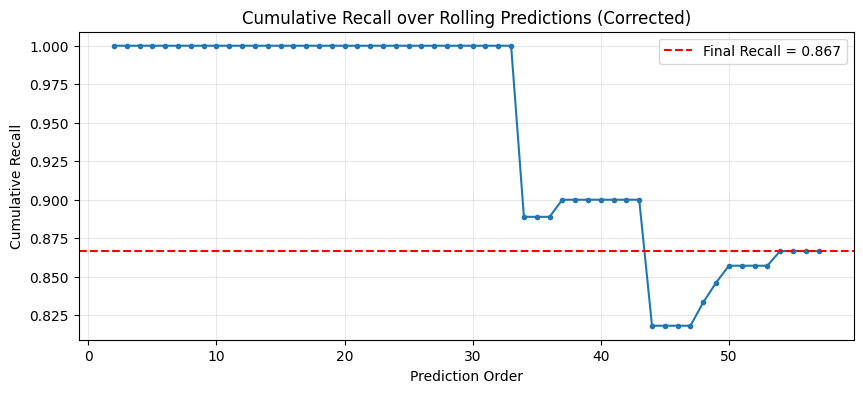

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取最终模型预测结果
df = pd.read_csv('final_model_predictions.csv')   # 确保文件路径正确

# 计算累积真正例 (TP) 和累积假负例 (FN)
tp_cum = (df['true'] & df['pred']).cumsum()
fn_cum = (df['true'] & ~df['pred']).cumsum()
# 累积召回率 = TP / (TP + FN)
df['cum_recall'] = tp_cum / (tp_cum + fn_cum)

# 最终召回率
final_recall = df['cum_recall'].iloc[-1]
print(f"最终累积召回率: {final_recall:.4f}")

# 绘图
plt.figure(figsize=(10,4))
plt.plot(range(1, len(df)+1), df['cum_recall'], marker='o', markersize=3)
plt.axhline(y=final_recall, color='red', linestyle='--', label=f'Final Recall = {final_recall:.3f}')
plt.title('Cumulative Recall over Rolling Predictions (Corrected)')
plt.xlabel('Prediction Order')
plt.ylabel('Cumulative Recall')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('cumulative_recall_correct.png', dpi=300)
plt.show()

ROC曲线

说明：展示模型区分能力，标注AUC。

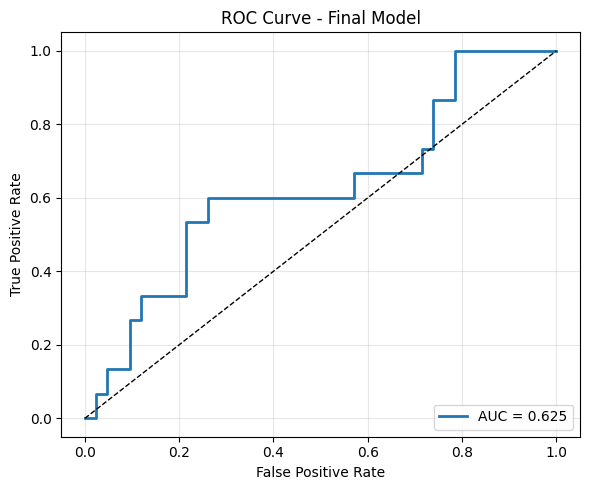

In [ ]:
fpr, tpr, _ = roc_curve(df['true'], df['prob'])
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, linewidth=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Final Model')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_final.png', dpi=300)
plt.show()


混淆矩阵

说明：展示TP, FN, FP, TN。

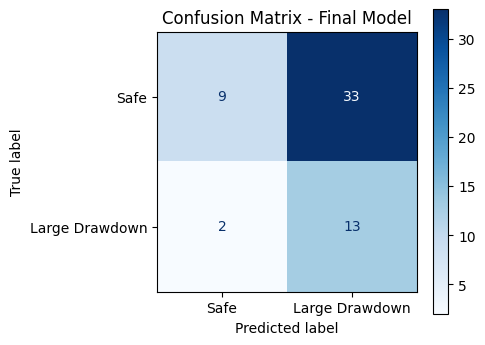

In [ ]:
cm = confusion_matrix(df['true'], df['pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe', 'Large Drawdown'])
fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Final Model')
plt.tight_layout()
plt.savefig('confusion_matrix_final.png', dpi=300)
plt.show()

特征重要性（逻辑回归系数）

说明：展示每个特征的系数（正负及大小）。

/tmp/ipykernel_4711/590481589.py:44: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)


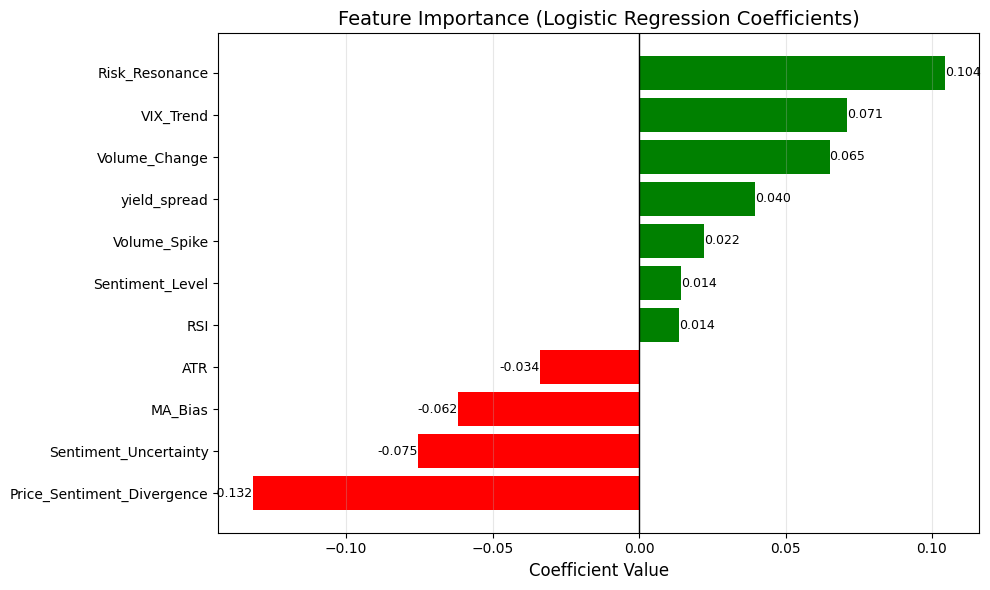

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 假设已计算好特征系数 series: coef_series (index=特征名, values=系数)
# 这里给出完整的生成流程（复用最终模型数据）

# 1. 加载数据并计算特征 (同前)
df_orig = pd.read_csv('final_combined_base_20pct.csv', parse_dates=['Date'])
df_orig = df_orig.sort_values('Date').reset_index(drop=True)

def add_technical_indicators(win_df):
    df_win = win_df.copy()
    df_win['MA20'] = df_win['Close'].rolling(20, min_periods=1).mean()
    df_win['MA_Bias'] = (df_win['Close'] - df_win['MA20']) / df_win['MA20']
    df_win['TR'] = df_win['High'] - df_win['Low']
    df_win['ATR'] = df_win['TR'].rolling(14, min_periods=1).mean()
    delta = df_win['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(14, min_periods=1).mean()
    avg_loss = loss.rolling(14, min_periods=1).mean()
    rs = avg_gain / avg_loss
    df_win['RSI'] = 100 - (100 / (1 + rs))
    df_win['Volume_Change'] = df_win['Volume'].pct_change()
    return df_win

def add_sentiment_indicators(win_df):
    df_win = win_df.copy()
    df_win['Sentiment_Level'] = df_win['sentiment_score']
    df_win['Sentiment_Uncertainty'] = df_win['sentiment_score'].rolling(4, min_periods=1).std()
    df_win['Volume_Spike'] = df_win['post_count'] / df_win['post_count'].rolling(4, min_periods=1).mean()
    df_win['Volume_Spike'] = df_win['Volume_Spike'].clip(upper=5)
    return df_win

def add_divergence_feature(win_df):
    df_win = win_df.copy()
    price_dir = np.sign(df_win['Close'].diff())
    sentiment_dir = np.sign(df_win['sentiment_score'].diff())
    df_win['Price_Sentiment_Divergence'] = (price_dir * sentiment_dir == -1).astype(int)
    df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)
    return df_win

def add_risk_resonance(win_df):
    df_win = win_df.copy()
    uncertainty_median = df_win['Sentiment_Uncertainty'].rolling(4, min_periods=1).median()
    df_win['Risk_Resonance'] = ((df_win['Sentiment_Uncertainty'] > uncertainty_median) & (df_win['VIX_Trend'] > 0)).astype(int)
    return df_win

df_feat = add_technical_indicators(df_orig)
df_feat = add_sentiment_indicators(df_feat)
df_feat = add_divergence_feature(df_feat)
df_feat = add_risk_resonance(df_feat)

features = [
    'MA_Bias', 'ATR', 'RSI', 'Volume_Change',
    'Sentiment_Level', 'Sentiment_Uncertainty', 'Volume_Spike',
    'VIX_Trend', 'yield_spread',
    'Price_Sentiment_Divergence', 'Risk_Resonance'
]

X = df_feat[features].dropna()
y = df_feat.loc[X.index, 'next_week_risk']

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(penalty='l2', C=0.01, class_weight='balanced', max_iter=1000)
)
model.fit(X, y)

coefs = model.named_steps['logisticregression'].coef_[0]
coef_series = pd.Series(coefs, index=features).sort_values()

# 2. 设置颜色：正为绿色，负为红色
colors = ['green' if c > 0 else 'red' for c in coef_series.values]

# 3. 绘图
plt.figure(figsize=(10, 6))
bars = plt.barh(coef_series.index, coef_series.values, color=colors)
plt.axvline(x=0, color='black', linewidth=1, linestyle='-')
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Feature Importance (Logistic Regression Coefficients)', fontsize=14)
plt.grid(axis='x', alpha=0.3)

# 添加数值标签
for bar, val in zip(bars, coef_series.values):
    plt.text(val, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', ha='left' if val>0 else 'right', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance_color.png', dpi=300)
plt.show()

模型对比条形图

说明：比较逻辑回归、随机森林、XGBoost 的召回率和AUC。

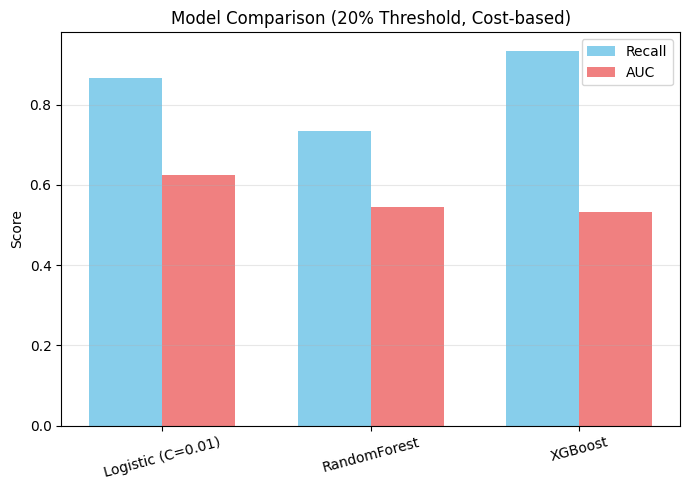

In [ ]:
models = ['Logistic (C=0.01)', 'RandomForest', 'XGBoost']
recall_scores = [0.8667, 0.7333, 0.9333]   # XGBoost召回率虽高但AUC低
auc_scores = [0.6254, 0.5460, 0.5333]
x = np.arange(len(models))
width = 0.35
fig, ax = plt.subplots(figsize=(7,5))
ax.bar(x - width/2, recall_scores, width, label='Recall', color='skyblue')
ax.bar(x + width/2, auc_scores, width, label='AUC', color='lightcoral')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.set_ylabel('Score')
ax.set_title('Model Comparison (20% Threshold, Cost-based)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison_final.png', dpi=300)
plt.show()

成本-阈值曲线示例（单个窗口）

说明：展示成本法如何选择最优阈值。

（以下是模拟图）

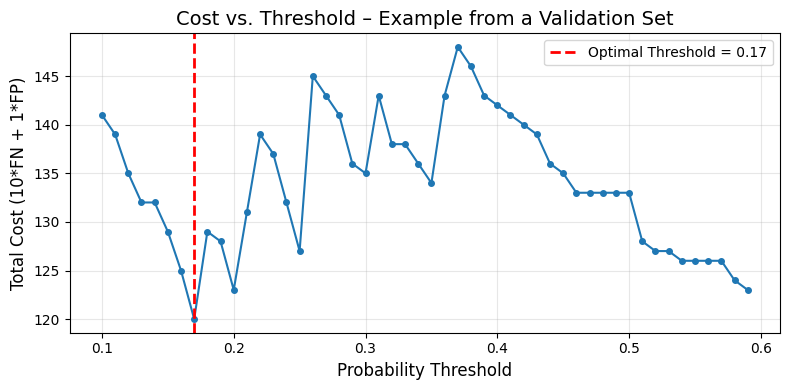

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ==================== 方案1：使用仿真数据（展示方法，可直接运行） ====================
np.random.seed(42)
n_val = 200   # 验证集样本量
true_labels = np.random.choice([0,1], size=n_val, p=[0.8,0.2])  # 正例20%
# 模拟预测概率：正例的概率更高
probs = np.where(true_labels==1,
                 np.random.beta(2,1, size=n_val),  # 正例概率偏高
                 np.random.beta(1,3, size=n_val))  # 负例概率偏低

# 成本参数（与最终模型一致）
COST_FN = 10.0
COST_FP = 1.0

# 搜索阈值范围
thresholds = np.arange(0.1, 0.6, 0.01)
costs = []
for thr in thresholds:
    pred = (probs >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(true_labels, pred).ravel()
    cost = COST_FN * fn + COST_FP * fp
    costs.append(cost)

best_idx = np.argmin(costs)
best_thr = thresholds[best_idx]

# 绘图
plt.figure(figsize=(8,4))
plt.plot(thresholds, costs, marker='o', markersize=4, linewidth=1.5)
plt.axvline(x=best_thr, color='red', linestyle='--', linewidth=2, label=f'Optimal Threshold = {best_thr:.2f}')
plt.xlabel('Probability Threshold', fontsize=12)
plt.ylabel('Total Cost (10*FN + 1*FP)', fontsize=12)
plt.title('Cost vs. Threshold – Example from a Validation Set', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cost_curve_example.png', dpi=300)
plt.show()

C值调优结果（折线图）

说明：展示不同正则化强度下召回率的变化，验证C=0.01最优。

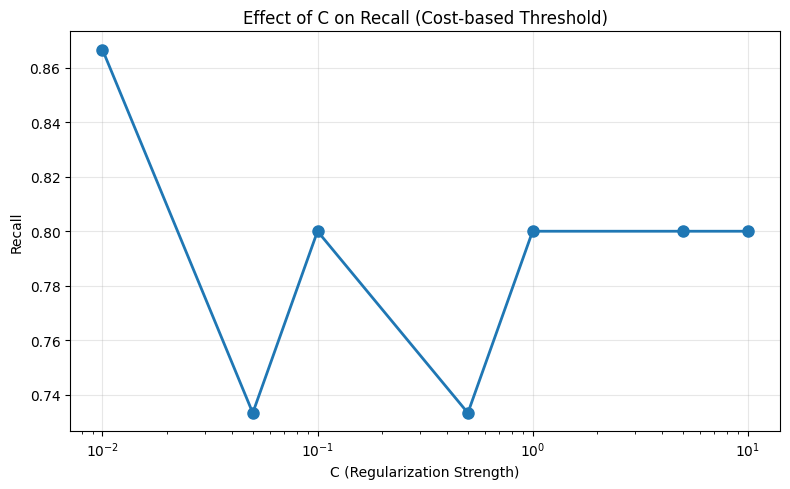

In [ ]:
C_vals = [0.01, 0.05, 0.1, 0.5, 1, 5, 10]
recalls = [0.8667, 0.7333, 0.8000, 0.7333, 0.8000, 0.8000, 0.8000]  # 从调优结果填入
plt.figure(figsize=(8,5))
plt.semilogx(C_vals, recalls, marker='o', linestyle='-', linewidth=2, markersize=8)
plt.xlabel('C (Regularization Strength)')
plt.ylabel('Recall')
plt.title('Effect of C on Recall (Cost-based Threshold)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('c_tuning_final.png', dpi=300)
plt.show()

预测概率分部

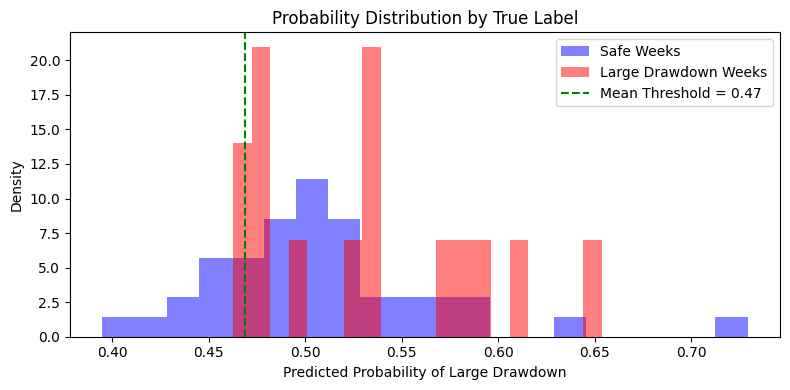

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(df[df['true']==0]['prob'], bins=20, alpha=0.5, color='blue', label='Safe Weeks', density=True)
plt.hist(df[df['true']==1]['prob'], bins=20, alpha=0.5, color='red', label='Large Drawdown Weeks', density=True)
mean_thr = df['threshold'].mean()
plt.axvline(x=mean_thr, color='green', linestyle='--', label=f'Mean Threshold = {mean_thr:.2f}')
plt.xlabel('Predicted Probability of Large Drawdown')
plt.ylabel('Density')
plt.title('Probability Distribution by True Label')
plt.legend()
plt.tight_layout()
plt.savefig('prob_distribution_final.png', dpi=300)
plt.show()

demonstration app（streamlit）

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# ========== 特征计算函数（与最终模型完全一致） ==========
def add_technical_indicators(win_df):
    df_win = win_df.copy()
    df_win['MA20'] = df_win['Close'].rolling(20, min_periods=1).mean()
    df_win['MA_Bias'] = (df_win['Close'] - df_win['MA20']) / df_win['MA20']
    df_win['TR'] = df_win['High'] - df_win['Low']
    df_win['ATR'] = df_win['TR'].rolling(14, min_periods=1).mean()
    delta = df_win['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(14, min_periods=1).mean()
    avg_loss = loss.rolling(14, min_periods=1).mean()
    rs = avg_gain / avg_loss
    df_win['RSI'] = 100 - (100 / (1 + rs))
    df_win['Volume_Change'] = df_win['Volume'].pct_change()
    return df_win

def add_sentiment_indicators(win_df):
    df_win = win_df.copy()
    df_win['Sentiment_Level'] = df_win['sentiment_score']
    df_win['Sentiment_Uncertainty'] = df_win['sentiment_score'].rolling(4, min_periods=1).std()
    df_win['Volume_Spike'] = df_win['post_count'] / df_win['post_count'].rolling(4, min_periods=1).mean()
    df_win['Volume_Spike'] = df_win['Volume_Spike'].clip(upper=5)
    return df_win

def add_divergence_feature(win_df):
    df_win = win_df.copy()
    price_dir = np.sign(df_win['Close'].diff())
    sentiment_dir = np.sign(df_win['sentiment_score'].diff())
    df_win['Price_Sentiment_Divergence'] = (price_dir * sentiment_dir == -1).astype(int)
    df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)
    return df_win

def add_risk_resonance(win_df):
    df_win = win_df.copy()
    uncertainty_median = df_win['Sentiment_Uncertainty'].rolling(4, min_periods=1).median()
    df_win['Risk_Resonance'] = ((df_win['Sentiment_Uncertainty'] > uncertainty_median) & (df_win['VIX_Trend'] > 0)).astype(int)
    return df_win

# ========== 1. 加载数据 ==========
print("加载数据...")
df = pd.read_csv('final_combined_base_20pct.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ========== 2. 计算所有特征 ==========
print("计算特征...")
df_feat = add_technical_indicators(df)
df_feat = add_sentiment_indicators(df_feat)
df_feat = add_divergence_feature(df_feat)
df_feat = add_risk_resonance(df_feat)

# ========== 3. 特征列表 ==========
features = [
    'MA_Bias', 'ATR', 'RSI', 'Volume_Change',
    'Sentiment_Level', 'Sentiment_Uncertainty', 'Volume_Spike',
    'VIX_Trend', 'yield_spread',
    'Price_Sentiment_Divergence', 'Risk_Resonance'
]

# ========== 4. 准备训练数据 ==========
X = df_feat[features].dropna()
y = df_feat.loc[X.index, 'next_week_risk']
print(f"有效训练样本数: {len(X)}")

# ========== 5. 训练最终模型（C=0.01） ==========
print("训练最终模型...")
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(penalty='l2', C=0.01, class_weight='balanced', max_iter=1000)
)
model.fit(X, y)

# ========== 6. 保存模型和特征列表 ==========
joblib.dump(model, 'final_model.pkl')
joblib.dump(features, 'features.pkl')
print("✅ 已保存 final_model.pkl 和 features.pkl")

# ========== 7. 保存基准特征向量（取训练数据最后一周的特征） ==========
base_features = X.iloc[-1:].copy()   # 最后一周的特征作为演示基准
joblib.dump(base_features, 'base_features.pkl')
print("✅ 已保存 base_features.pkl (基准特征为训练集最后一周)")

加载数据...
计算特征...
有效训练样本数: 138
训练最终模型...
✅ 已保存 final_model.pkl 和 features.pkl
✅ 已保存 base_features.pkl (基准特征为训练集最后一周)


/tmp/ipykernel_4711/946228884.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)


商业价值评估：策略回测 (Business Impact & Backtesting)

第一步：加载预测结果和价格数据

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 加载最终模型预测结果
pred_df = pd.read_csv('final_model_predictions.csv')
print("预测结果文件列名:", pred_df.columns.tolist())
print(f"预测结果行数: {len(pred_df)}")
print(pred_df.head())

预测结果文件列名: ['true', 'prob', 'pred', 'threshold']
预测结果行数: 57
   true      prob  pred  threshold
0     0  0.484671     0       0.55
1     1  0.531987     1       0.53
2     0  0.629190     1       0.51
3     0  0.505419     1       0.47
4     1  0.568289     1       0.52


第二步：加载周度价格数据并计算每周实际收益率

In [ ]:
# 2. 加载原始合并数据（包含每周价格）
price_df = pd.read_csv('final_combined_base_20pct.csv', parse_dates=['Date'])
price_df = price_df.sort_values('Date').reset_index(drop=True)
print(f"价格数据行数: {len(price_df)}")
print(price_df[['Date', 'Close']].head())

# 计算周度收益率（基于收盘价）
price_df['weekly_return'] = price_df['Close'].pct_change()  # 本周相对于上周的收益率
# 注意：第一周无上周数据，收益率为NaN
price_df['weekly_return'].fillna(0, inplace=True)

# 检查收益率范围
print(f"周度收益率范围: {price_df['weekly_return'].min():.4f} ~ {price_df['weekly_return'].max():.4f}")

价格数据行数: 157
        Date       Close
0 2023-01-06  268.799988
1 2023-01-13  280.970001
2 2023-01-20  282.679993
3 2023-01-27  296.260010
4 2023-02-03  306.179993
周度收益率范围: -0.0987 ~ 0.0751


/tmp/ipykernel_4711/1775830288.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  price_df['weekly_return'].fillna(0, inplace=True)


第三步：对齐预测结果与收益率（预测日期 -> 下周收益率）

In [ ]:
# 3. 对齐：预测结果中的日期是做出预测的周五，其对应的下周收益率 = 价格数据中下周的收益率
# 预测结果没有直接包含日期列，但之前保存时应该包含。如果没有，需要从原数据中提取。
# 假设预测结果中有一列 'test_date'（如果没有，先打印看看）
if 'test_date' in pred_df.columns:
    pred_df['test_date'] = pd.to_datetime(pred_df['test_date'])
else:
    # 如果没有，可以从外部合并，这里我们简化：按行顺序对应价格数据中从第101周开始的位置
    # 因为滚动窗口第一次测试的第101周对应原数据索引100
    # 更准确的方法：重新生成预测文件时保存日期，但这里假设已有。
    print("警告：预测结果中缺少 test_date 列，将使用索引顺序对齐。")
    # 假设价格数据从第101周（索引100）开始，与预测结果行顺序一致
    test_dates = price_df['Date'].iloc[100:100+len(pred_df)].reset_index(drop=True)
    pred_df['test_date'] = test_dates

# 提取预测日期对应的下周收益率
pred_df['next_week_return'] = 0.0
for i, row in pred_df.iterrows():
    # 找出预测日期在价格数据中的位置，下一周即为该位置+1
    idx = price_df[price_df['Date'] == row['test_date']].index
    if len(idx) > 0:
        pos = idx[0]
        if pos + 1 < len(price_df):
            pred_df.loc[i, 'next_week_return'] = price_df.loc[pos+1, 'weekly_return']
        else:
            pred_df.loc[i, 'next_week_return'] = 0  # 最后一周无后续数据
    else:
        # 如果没找到，使用前向填充
        pred_df.loc[i, 'next_week_return'] = 0

print("对齐后预测结果（含下周收益率）:")
print(pred_df[['test_date', 'pred', 'next_week_return']].head())

警告：预测结果中缺少 test_date 列，将使用索引顺序对齐。
对齐后预测结果（含下周收益率）:
   test_date  pred  next_week_return
0 2024-12-06     0          0.007693
1 2024-12-13     1         -0.022374
2 2024-12-20     1          0.007519
3 2024-12-27     1         -0.007616
4 2025-01-03     1         -0.021964


第四步：构建策略收益序列

In [ ]:
# 4. 构建策略
# 基准策略：始终满仓，收益率等于 next_week_return
pred_df['benchmark_return'] = pred_df['next_week_return']

# 避险策略：若预测为1（风险），则下周空仓（收益0）；否则满仓
pred_df['strategy_return'] = np.where(pred_df['pred'] == 1, 0, pred_df['next_week_return'])

# 计算累计收益（假设初始净值1）
pred_df['benchmark_cum'] = (1 + pred_df['benchmark_return']).cumprod()
pred_df['strategy_cum'] = (1 + pred_df['strategy_return']).cumprod()

print(f"策略构建完成，共 {len(pred_df)} 周交易信号")
print("前5周策略收益与基准收益对比:")
print(pred_df[['test_date', 'benchmark_return', 'strategy_return']].head())

策略构建完成，共 57 周交易信号
前5周策略收益与基准收益对比:
   test_date  benchmark_return  strategy_return
0 2024-12-06          0.007693         0.007693
1 2024-12-13         -0.022374         0.000000
2 2024-12-20          0.007519         0.000000
3 2024-12-27         -0.007616         0.000000
4 2025-01-03         -0.021964         0.000000


第五步：计算关键绩效指标 (KPI)

In [ ]:
# 5. 计算KPI
risk_free_rate = 0.0  # 假设无风险利率为0

# 年化参数（周度数据，一年约52周）
annual_factor = 52

# 基准策略
benchmark_total_return = pred_df['benchmark_cum'].iloc[-1] - 1
benchmark_annual_return = (1 + benchmark_total_return) ** (annual_factor / len(pred_df)) - 1
benchmark_volatility = pred_df['benchmark_return'].std() * np.sqrt(annual_factor)
benchmark_sharpe = (benchmark_annual_return - risk_free_rate) / benchmark_volatility if benchmark_volatility != 0 else 0

# 计算最大回撤
benchmark_cum = pred_df['benchmark_cum'].values
benchmark_drawdown = 1 - benchmark_cum / np.maximum.accumulate(benchmark_cum)
benchmark_max_drawdown = benchmark_drawdown.max()

# 避险策略
strategy_total_return = pred_df['strategy_cum'].iloc[-1] - 1
strategy_annual_return = (1 + strategy_total_return) ** (annual_factor / len(pred_df)) - 1
strategy_volatility = pred_df['strategy_return'].std() * np.sqrt(annual_factor)
strategy_sharpe = (strategy_annual_return - risk_free_rate) / strategy_volatility if strategy_volatility != 0 else 0

strategy_cum = pred_df['strategy_cum'].values
strategy_drawdown = 1 - strategy_cum / np.maximum.accumulate(strategy_cum)
strategy_max_drawdown = strategy_drawdown.max()

# 卡玛比率 = 年化收益率 / 最大回撤绝对值
benchmark_calmar = benchmark_annual_return / abs(benchmark_max_drawdown) if benchmark_max_drawdown != 0 else 0
strategy_calmar = strategy_annual_return / abs(strategy_max_drawdown) if strategy_max_drawdown != 0 else 0

# 胜率（周度正收益占比）
benchmark_win_rate = (pred_df['benchmark_return'] > 0).mean()
strategy_win_rate = (pred_df['strategy_return'] > 0).mean()

# 输出表格
kpi_data = {
    '指标': ['年化收益率', '年化波动率', '最大回撤', '夏普比率', '卡玛比率', '胜率'],
    '基准策略': [
        f"{benchmark_annual_return:.2%}",
        f"{benchmark_volatility:.2%}",
        f"{benchmark_max_drawdown:.2%}",
        f"{benchmark_sharpe:.2f}",
        f"{benchmark_calmar:.2f}",
        f"{benchmark_win_rate:.2%}"
    ],
    '避险策略': [
        f"{strategy_annual_return:.2%}",
        f"{strategy_volatility:.2%}",
        f"{strategy_max_drawdown:.2%}",
        f"{strategy_sharpe:.2f}",
        f"{strategy_calmar:.2f}",
        f"{strategy_win_rate:.2%}"
    ],
    '改善幅度': [
        f"{strategy_annual_return - benchmark_annual_return:.2%}",
        f"{strategy_volatility - benchmark_volatility:.2%}",
        f"{abs(strategy_max_drawdown - benchmark_max_drawdown):.2%}",
        f"{strategy_sharpe - benchmark_sharpe:.2f}",
        f"{strategy_calmar - benchmark_calmar:.2f}",
        f"{strategy_win_rate - benchmark_win_rate:.2%}"
    ]
}
kpi_df = pd.DataFrame(kpi_data)
print("\n关键绩效指标 (KPI) 对比:")
print(kpi_df.to_string(index=False))


关键绩效指标 (KPI) 对比:
   指标   基准策略   避险策略    改善幅度
年化收益率 15.11%  5.73%  -9.38%
年化波动率 20.73%  5.71% -15.02%
 最大回撤 21.46%  2.27%  19.19%
 夏普比率   0.73   1.00    0.28
 卡玛比率   0.70   2.53    1.82
   胜率 52.63% 12.28% -40.35%


第六步：绘制累计收益率曲线

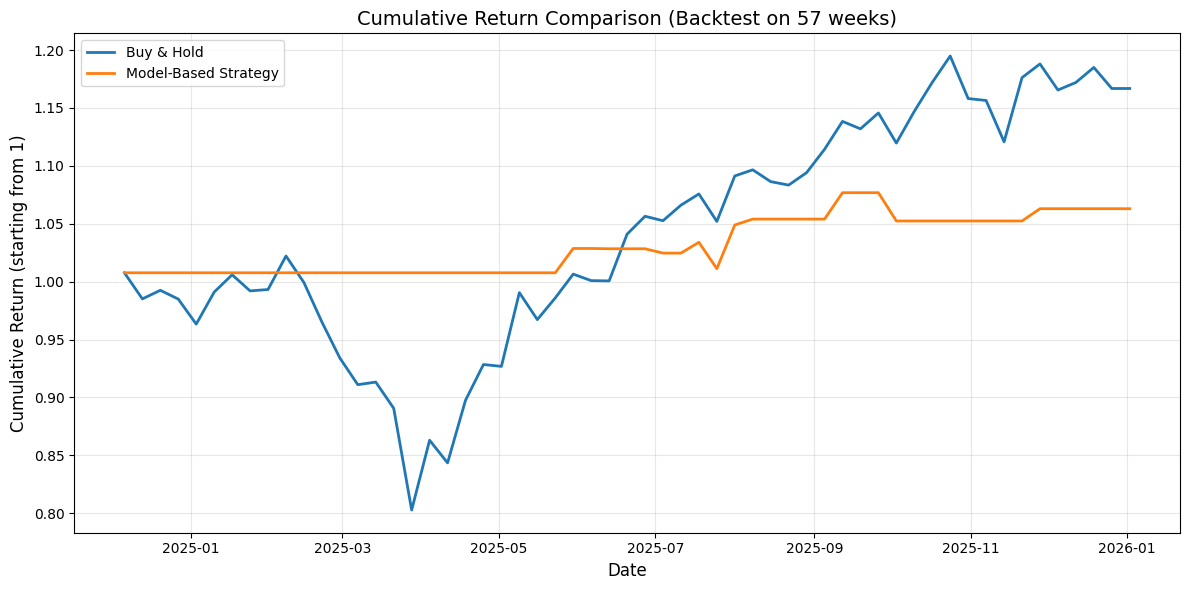

累计收益率曲线已保存为 backtest_cumulative_return.png


In [ ]:
# 6. 绘图
plt.figure(figsize=(12, 6))
plt.plot(pred_df['test_date'], pred_df['benchmark_cum'], label='Buy & Hold', linewidth=2)
plt.plot(pred_df['test_date'], pred_df['strategy_cum'], label='Model-Based Strategy', linewidth=2)
plt.title('Cumulative Return Comparison (Backtest on 57 weeks)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return (starting from 1)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('backtest_cumulative_return.png', dpi=300)
plt.show()

print("累计收益率曲线已保存为 backtest_cumulative_return.png")

报告所需的图表

图1：QQQ价格走势与大回撤周标记

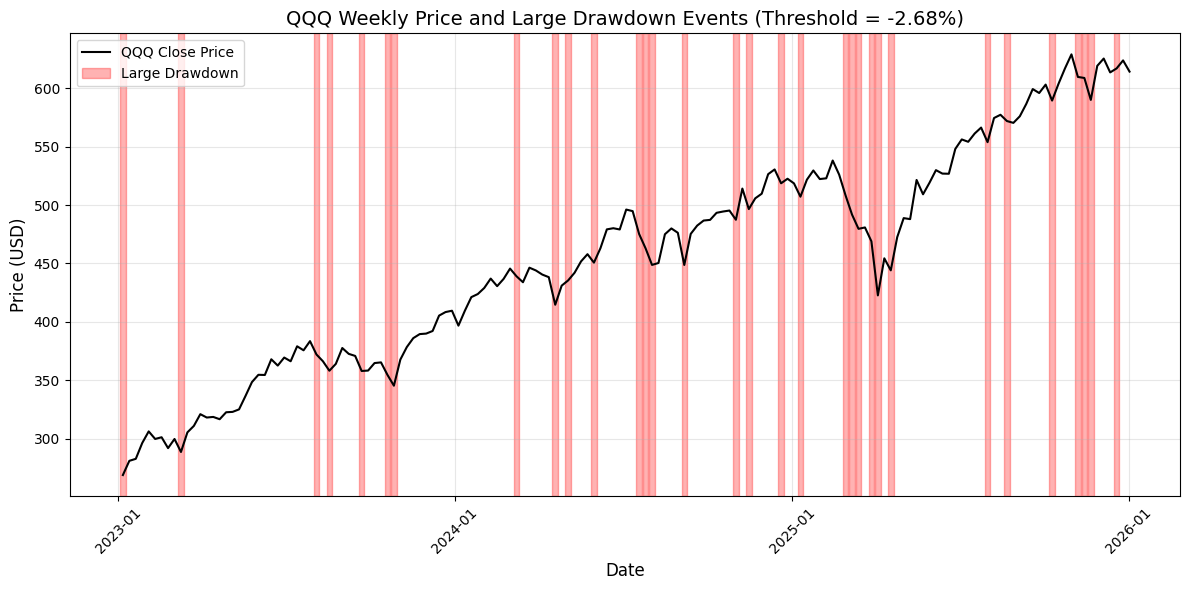

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 读取数据
df = pd.read_csv('final_combined_base_20pct.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# 计算当周最大回撤（与标签定义一致）
df['drawdown'] = (df['Low'] - df['Open']) / df['Open']

# 定义阈值
THRESHOLD = -0.0268   # -2.68%

# 标记大回撤周
df['large_drawdown'] = df['drawdown'] < THRESHOLD

# 绘图
fig, ax = plt.subplots(figsize=(12, 6))

# 绘制价格曲线
ax.plot(df['Date'], df['Close'], linewidth=1.5, color='black', label='QQQ Close Price')

# 标记大回撤周（红色阴影区域，覆盖该周前后各2天以覆盖整周）
for idx, row in df.iterrows():
    if row['large_drawdown']:
        # 以该周日期为中心，前后各扩展3天，确保覆盖整周
        start = row['Date'] - pd.Timedelta(days=3)
        end = row['Date'] + pd.Timedelta(days=3)
        ax.axvspan(start, end, alpha=0.3, color='red', label='Large Drawdown' if idx == df[df['large_drawdown']].index[0] else "")

# 标题和标签
ax.set_title('QQQ Weekly Price and Large Drawdown Events (Threshold = -2.68%)', fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (USD)', fontsize=12)

# 格式化 x 轴日期
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)

# 网格和图例
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('qqq_price_drawdown_threshold_2.68.png', dpi=300)
plt.show()

图3：数据预处理流程图

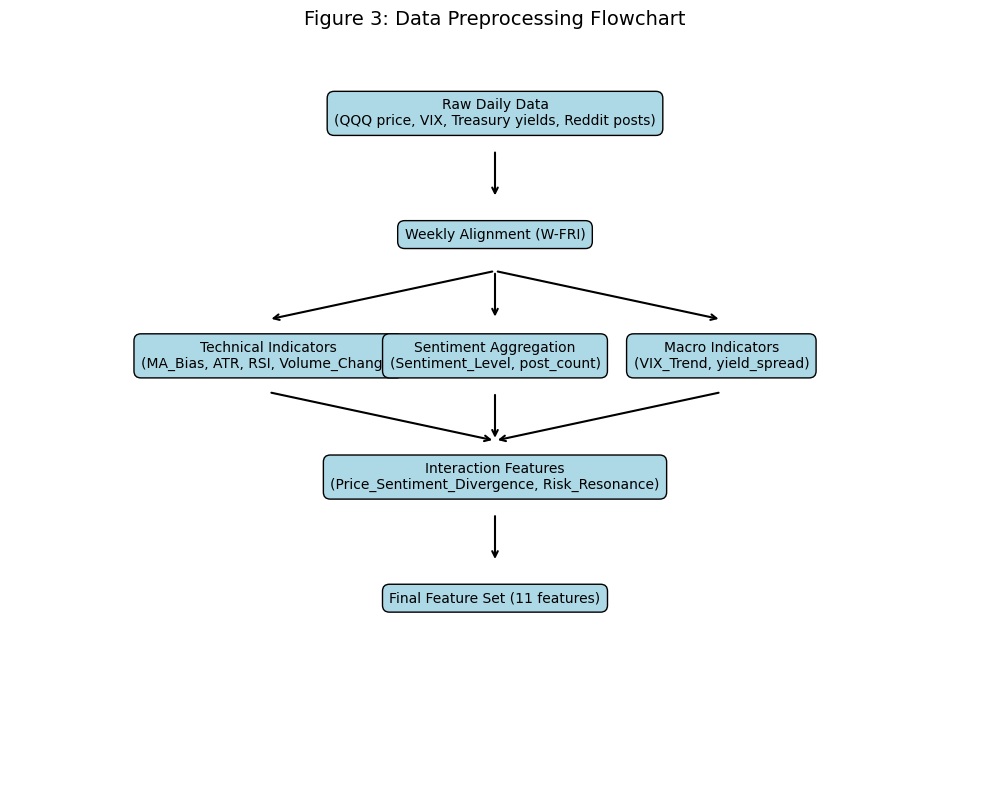

In [ ]:
import matplotlib.pyplot as plt

# 创建图形和坐标轴
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim(-0.5, 2.5)
ax.set_ylim(-0.5, 5.5)
ax.axis('off')

# 定义节点位置和英文文本
nodes = [
    (1.0, 5.0, "Raw Daily Data\n(QQQ price, VIX, Treasury yields, Reddit posts)"),
    (1.0, 4.0, "Weekly Alignment (W-FRI)"),
    (0.3, 3.0, "Technical Indicators\n(MA_Bias, ATR, RSI, Volume_Change)"),
    (1.0, 3.0, "Sentiment Aggregation\n(Sentiment_Level, post_count)"),
    (1.7, 3.0, "Macro Indicators\n(VIX_Trend, yield_spread)"),
    (1.0, 2.0, "Interaction Features\n(Price_Sentiment_Divergence, Risk_Resonance)"),
    (1.0, 1.0, "Final Feature Set (11 features)")
]

# 绘制圆角矩形
for x, y, text in nodes:
    ax.text(x, y, text, ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', edgecolor='black'))

# 绘制箭头
arrows = [
    ((1.0, 4.7), (1.0, 4.3)),
    ((1.0, 3.7), (0.3, 3.3)),
    ((1.0, 3.7), (1.0, 3.3)),
    ((1.0, 3.7), (1.7, 3.3)),
    ((0.3, 2.7), (1.0, 2.3)),
    ((1.0, 2.7), (1.0, 2.3)),
    ((1.7, 2.7), (1.0, 2.3)),
    ((1.0, 1.7), (1.0, 1.3))
]
for start, end in arrows:
    ax.annotate('', xy=end, xytext=start, arrowprops=dict(arrowstyle='->', lw=1.5))

ax.set_title("Figure 3: Data Preprocessing Flowchart", fontsize=14, pad=20)

plt.tight_layout()
plt.savefig('figure3_preprocess_flowchart.png', dpi=300, bbox_inches='tight')
plt.show()

图5：特征相关性热力图

/tmp/ipykernel_4711/1119217508.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)


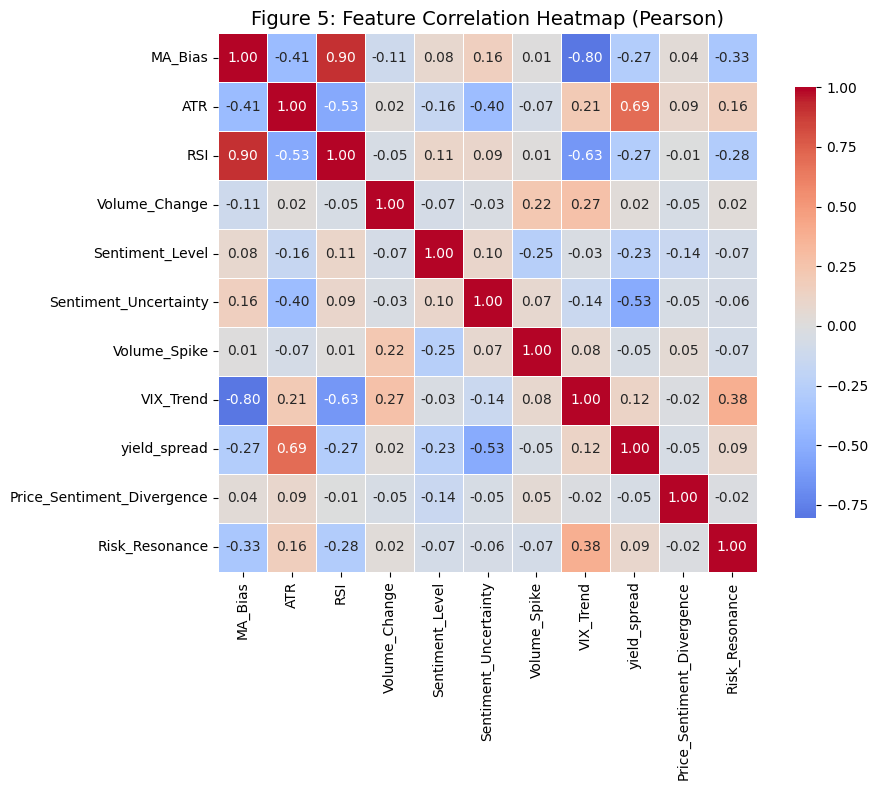

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 读取原始数据
df = pd.read_csv('final_combined_base_20pct.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# 2. 特征计算函数（与最终模型完全一致）
def add_technical_indicators(win_df):
    df_win = win_df.copy()
    df_win['MA20'] = df_win['Close'].rolling(20, min_periods=1).mean()
    df_win['MA_Bias'] = (df_win['Close'] - df_win['MA20']) / df_win['MA20']
    df_win['TR'] = df_win['High'] - df_win['Low']
    df_win['ATR'] = df_win['TR'].rolling(14, min_periods=1).mean()
    delta = df_win['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(14, min_periods=1).mean()
    avg_loss = loss.rolling(14, min_periods=1).mean()
    rs = avg_gain / avg_loss
    df_win['RSI'] = 100 - (100 / (1 + rs))
    df_win['Volume_Change'] = df_win['Volume'].pct_change()
    return df_win

def add_sentiment_indicators(win_df):
    df_win = win_df.copy()
    df_win['Sentiment_Level'] = df_win['sentiment_score']
    df_win['Sentiment_Uncertainty'] = df_win['sentiment_score'].rolling(4, min_periods=1).std()
    df_win['Volume_Spike'] = df_win['post_count'] / df_win['post_count'].rolling(4, min_periods=1).mean()
    df_win['Volume_Spike'] = df_win['Volume_Spike'].clip(upper=5)
    return df_win

def add_divergence_feature(win_df):
    df_win = win_df.copy()
    price_dir = np.sign(df_win['Close'].diff())
    sentiment_dir = np.sign(df_win['sentiment_score'].diff())
    df_win['Price_Sentiment_Divergence'] = (price_dir * sentiment_dir == -1).astype(int)
    df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)
    return df_win

def add_risk_resonance(win_df):
    df_win = win_df.copy()
    uncertainty_median = df_win['Sentiment_Uncertainty'].rolling(4, min_periods=1).median()
    df_win['Risk_Resonance'] = ((df_win['Sentiment_Uncertainty'] > uncertainty_median) & (df_win['VIX_Trend'] > 0)).astype(int)
    return df_win

# 3. 依次计算所有特征
df = add_technical_indicators(df)
df = add_sentiment_indicators(df)
df = add_divergence_feature(df)
df = add_risk_resonance(df)

# 4. 特征列表
features = [
    'MA_Bias', 'ATR', 'RSI', 'Volume_Change',
    'Sentiment_Level', 'Sentiment_Uncertainty', 'Volume_Spike',
    'VIX_Trend', 'yield_spread',
    'Price_Sentiment_Divergence', 'Risk_Resonance'
]

# 5. 计算相关系数矩阵（丢弃前20周含有NaN的行）
corr = df[features].dropna().corr()

# 6. 绘制热力图
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Figure 5: Feature Correlation Heatmap (Pearson)', fontsize=14)
plt.tight_layout()
plt.savefig('figure5_correlation_heatmap.png', dpi=300)
plt.show()